# Final Validation — Seoul Bike Sharing 2015–2024


This is the confirmatory stage of the project. Three candidates were frozen by Notebook 04 under temporal cross-validation by meteorological year, restricted to the normal operating regime. Here, each candidate is evaluated exactly once on the sealed temporal holdout covering December 2023 through November 2024. No model is retrained, no hyperparameter is changed, and the holdout is opened by a single audited function so that no notebook variable can pass it into a modeling call.

All logic is implemented in `src.final_validation` and `src.final_validation_reports`. The notebook remains a thin presentation layer: it declares a configuration, calls a small number of public functions, and displays their outputs.


## 1. Confirmatory Objective and Pre-registered Protocol

The pre-registered Champion is `CatBoostRegressor`. The holdout is not treated as a new model search: the decision rule is defined before the holdout is opened, and it can only confirm or fail to confirm the pre-registered candidate. CatBoost is confirmed when its holdout MAE is no greater than 1.05 times the smallest MAE among the three candidates and, simultaneously, its holdout R² is no less than the highest R² among the three minus 0.02. If either condition is not met, the best holdout performance is identified descriptively; however, the Notebook 04 manifest is not changed, the search is not reopened, and no model is retrained.

Two opposite sign conventions are adopted and stated explicitly to prevent inverted interpretations. Bias is defined as the mean of ŷ − y, so positive bias indicates overestimation. The residual used in graphical diagnostics is defined as y − ŷ, so a positive residual indicates underestimation.


> ### Insight
>
> The confirmation rule is pre-registered before the holdout is opened, which preserves the confirmatory nature of this stage. A numerically small difference between candidates is not described as substantive superiority, and any definitive future change of Champion would require a new independent temporal window.


In [1]:

import sys
import warnings
from pathlib import Path
PROJECT_ROOT = next(
    filter(
        lambda candidate: (
            (candidate / 'src').is_dir()
            and (candidate / 'notebooks').is_dir()
        ),
        (Path.cwd(), *Path.cwd().parents),
    )
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from matplotlib import pyplot as plt
from src import final_validation_reports as reports
from src.final_validation import (
    FinalValidationConfig,
    prepare_final_validation,
    run_final_validation,
    run_shap_validation,
)
from src.i18n import make_lang
from src.plotting import set_graph_parameters

set_graph_parameters()
plt.rcParams['axes.grid'] = False
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

lang = make_lang('en')
config = FinalValidationConfig()

In [2]:
reports.protocol_report(config, lang=lang)

,Item,Value
0,Pre-registered Champion,CatBoostRegressor
1,MAE rule,Champion MAE ≤ 1.05 × the lowest MAE among the...
2,R² rule,Champion R² ≥ the highest R² among the three −...
3,MAE tolerance (ratio),1.05
4,R² margin,0.02
5,Decision if both conditions are met,Champion confirmed
6,Decision otherwise,Champion not confirmed
7,Search reopening,Does not occur; a new temporal window would be...


## 2. Environment and Provenance

Validation is prepared before the holdout is opened. The interpreter is verified, the candidate manifest is checked against the Notebook 05 contract, the provenance of all three frozen pipelines is confirmed against the manifest, and their originating selection runs are audited as completed and verified. The environment and the versions of numerically relevant libraries are recorded to support reproducibility.


In [3]:
plan = prepare_final_validation(config)
reports.provenance_report(plan, lang=lang)

,Item,Value
0,Environment,Bike-Sharing
1,Interpreter,Bike-Sharing/python.exe
2,Python version,3.10.20
3,Environment fingerprint,8f80d9216d47a792
4,Dataset fingerprint,24f188a95febd94d
5,Regime fingerprint,1043b392ad5e2806
6,CV strategy version,ForwardMeteorologicalYearSplit_v3_normal_opera...
7,Selection code version,temporal_optimizer_v7
8,Final-validation code version,final_validation_v1
9,scikit-learn,1.3.2


## 3. Frozen Candidate Manifest

The three candidates are exactly those frozen by Notebook 04. Each pipeline carries a provenance stamp that reproduces the identity of the run that selected it, and the artifact SHA-256 is recorded for auditability. Each candidate’s cross-validation position is shown only as a reference; no holdout metric is written back to the selection runs.


In [4]:
reports.candidates_report(plan, lang=lang)

,Role,Estimator,Source run ID,Mean MAE (CV),Weighted MAE (CV),Mean R² (CV),Artifact SHA-256,Provenance verified
0,Champion,CatBoostRegressor,2106a5bf79e945f7a4a9d161e2ee01d3,820.401191,840.165428,0.838691,57195bd3badc,True
1,Challenger,HistGradientBoostingRegressor,381e7061d8ef440e917c792ab38e59f3,815.019786,852.950285,0.843872,b27ab507627c,True
2,Challenger,RandomForestRegressor,030ef18ea01d46caacbeb2bc0765da61,847.613928,919.734700,0.831417,3518c691fe7c,True


## 4. Single Holdout Materialization

The holdout is opened exactly once, after all provenance invariants have been verified. The development fingerprint and the operating-regime fingerprint are recomputed and checked against the manifest, and the window is required to contain exactly 8,784 hourly observations. The 744 hours from December 2024, which exist in the source but occur after the holdout, are counted and discarded and are never returned. An idempotent re-execution reuses persisted results instead of reopening the holdout.


In [5]:
results = run_final_validation(config, plan=plan)
reports.holdout_seal_report(results, lang=lang)

,Item,Value
0,Holdout window,None — None
1,Holdout observations,None
2,Development window,loaded from cache
3,Development observations,None
4,Dec/2024 hours discarded,None
5,Dataset fingerprint,24f188a95febd94d
6,Holdout fingerprint,None
7,Regime fingerprint,1043b392ad5e2806
8,Result source,results reused from cache


## 5. Final Predictions and Metrics

Each candidate predicts the same holdout exactly once, and the predictions are required to be finite, non-negative, and aligned with the observations. Metrics include MAE, RMSE, R², median absolute error, mean bias, and absolute-error quantiles. WAPE is used instead of conventional MAPE, whose definition is problematic when demand contains zeros; WAPE is the sum of absolute errors divided by the sum of absolute observed values. Each metric’s difference from the cross-validation aggregate is also reported.


In [6]:
reports.comparison_report(results, lang=lang)

,Role,Estimator,Run ID,MAE (holdout),RMSE (holdout),R² (holdout),WAPE (holdout),Median absolute error,Mean bias (ŷ−y),Mean MAE (CV),Mean RMSE (CV),Mean R² (CV),Holdout MAE − CV
0,Champion,CatBoostRegressor,2106a5bf79e945f7a4a9d161e2ee01d3,1118.087076,1605.704072,0.839276,0.230634,768.263229,1000.094704,820.401191,1242.845648,0.838691,297.685885
1,Challenger,HistGradientBoostingRegressor,381e7061d8ef440e917c792ab38e59f3,1424.856938,2069.719454,0.732962,0.293913,893.435660,1278.903696,815.019786,1243.003730,0.843872,609.837151
2,Challenger,RandomForestRegressor,030ef18ea01d46caacbeb2bc0765da61,1593.437122,2322.236136,0.663828,0.328687,987.957226,1407.498130,847.613928,1306.470196,0.831417,745.823194


In [7]:
reports.metrics_report(results, lang=lang)

,Role,Estimator,MAE,RMSE,R²,WAPE,Median absolute error,Mean bias (ŷ−y),Mean |residual|,|Error| q90,|Error| q95,|Error| q99,Holdout MAE − CV,Holdout R² − CV
0,Champion,CatBoostRegressor,1118.087076,1605.704072,0.839276,0.230634,768.263229,1000.094704,1118.087076,2613.685060,3395.304977,5168.613219,297.685885,0.000585
1,Challenger,HistGradientBoostingRegressor,1424.856938,2069.719454,0.732962,0.293913,893.435660,1278.903696,1424.856938,3515.077840,4453.414137,6570.805356,609.837151,-0.110910
2,Challenger,RandomForestRegressor,1593.437122,2322.236136,0.663828,0.328687,987.957226,1407.498130,1593.437122,3859.401617,4911.211065,7829.631313,745.823194,-0.167589


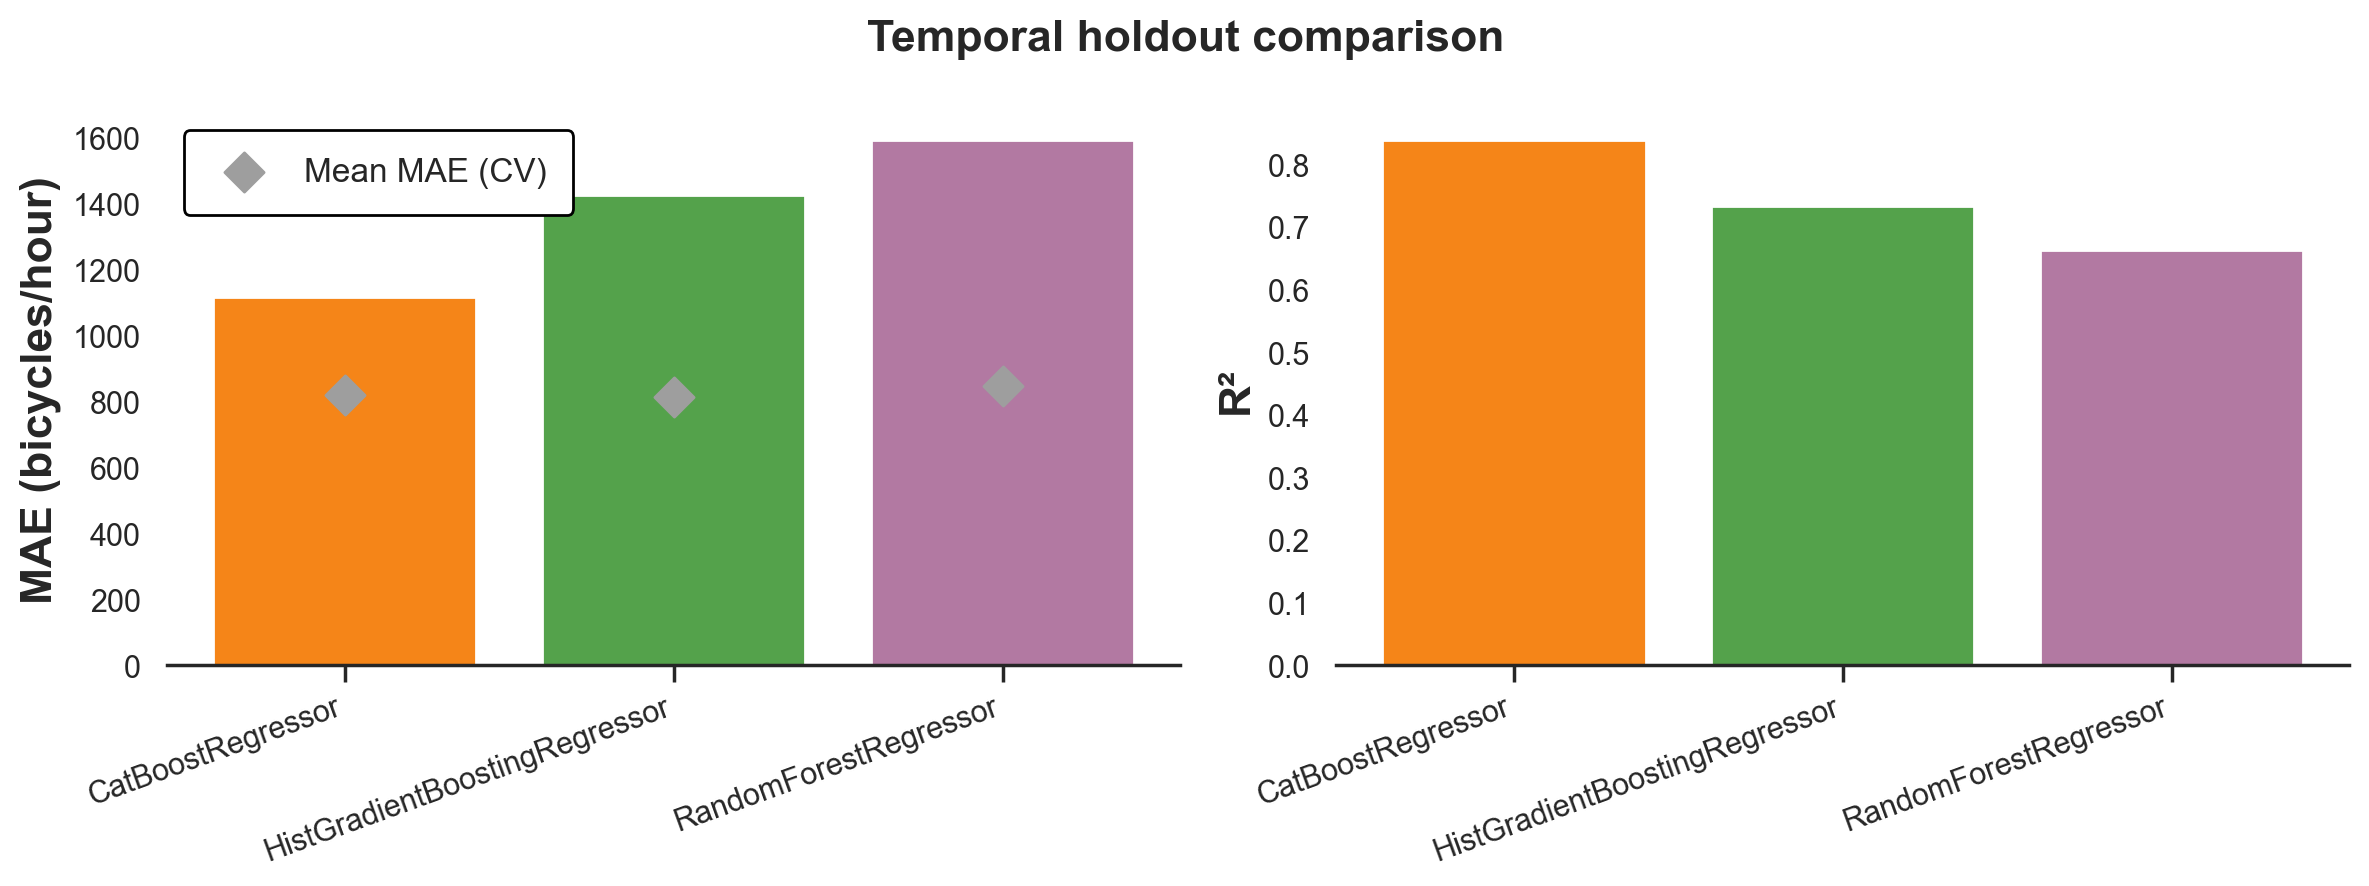

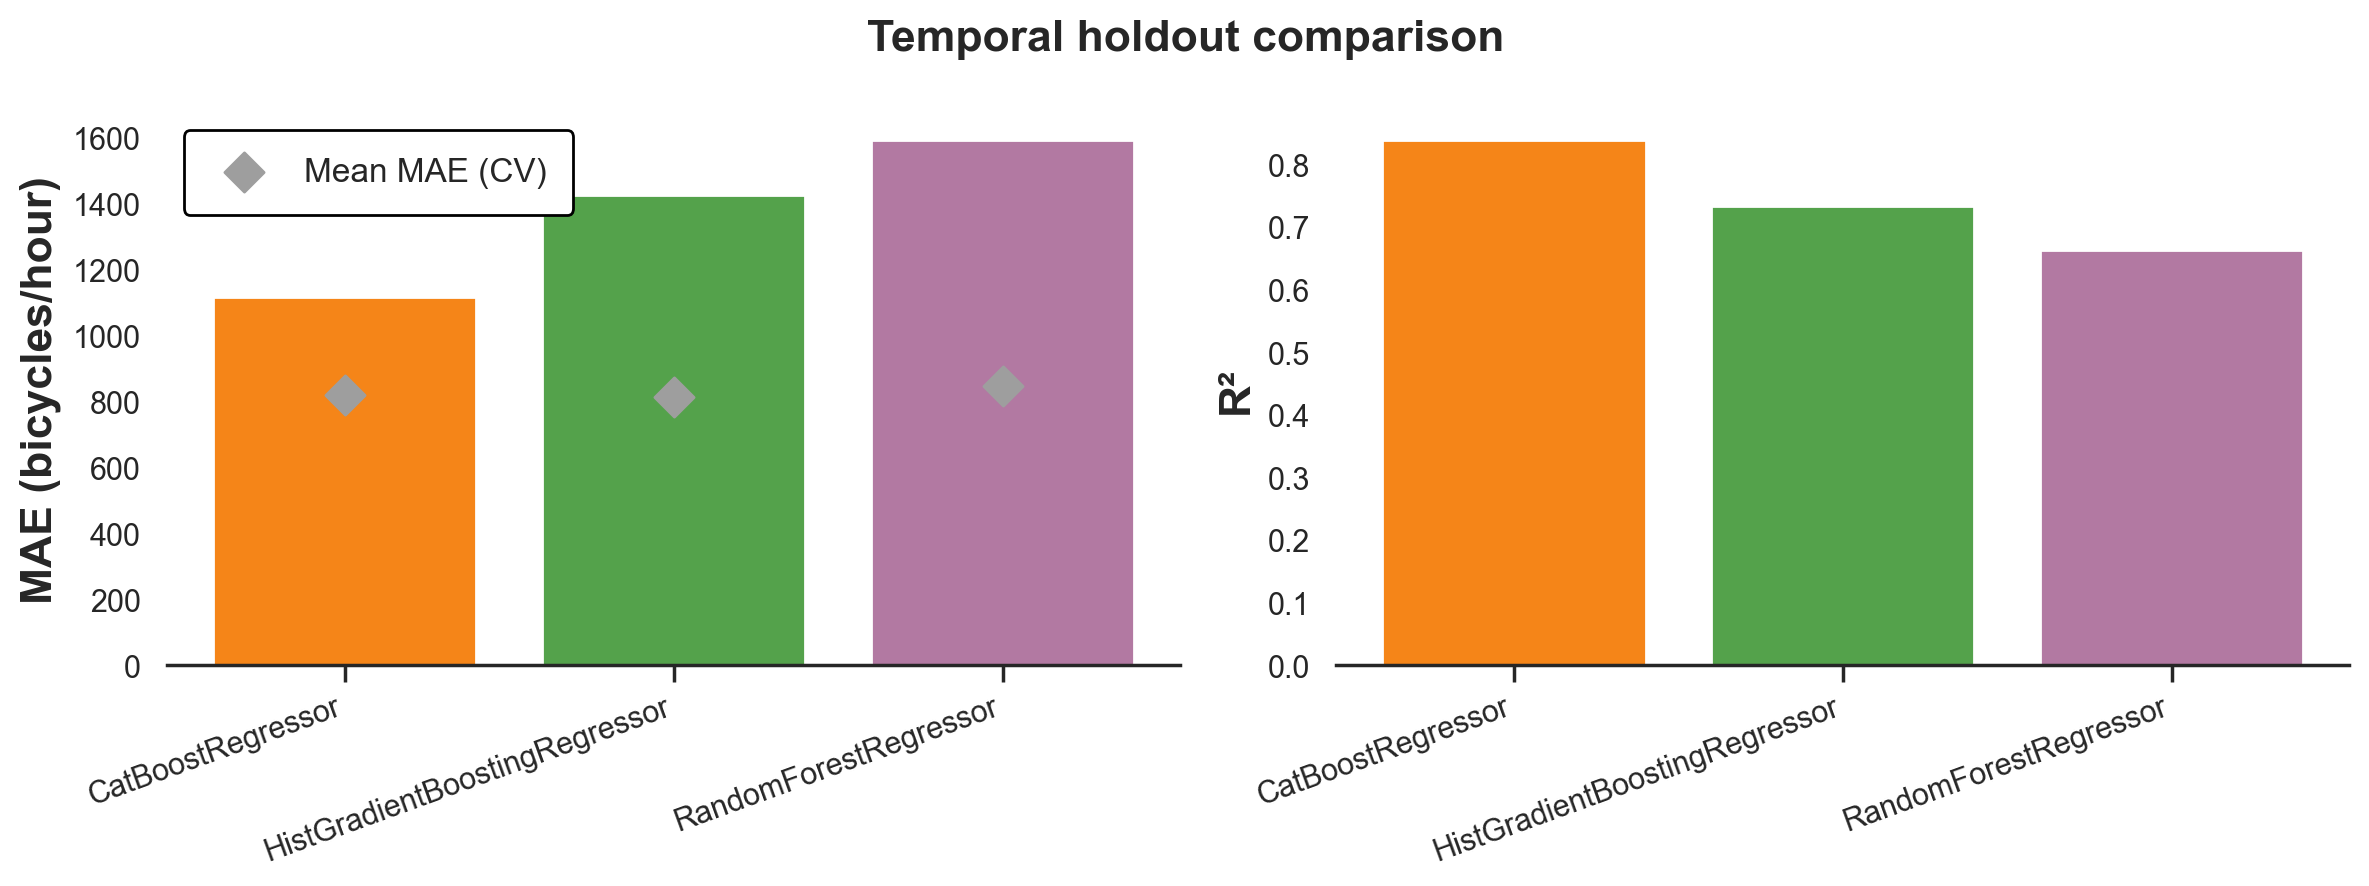

In [8]:
reports.plot_comparison(results, lang=lang)

## 6. Champion Confirmation

The pre-registered rule is applied to the observed holdout results. The resulting decision and the conditions that produced it are presented in tabular form, and a value-dependent narrative is generated dynamically by the reporting layer because it cannot be written before execution.


In [9]:
reports.confirmation_report(results, lang=lang)

,Item,Value
0,Decision,Champion confirmed
1,Champion MAE,1118.087
2,Champion R²,0.8393
3,Lowest MAE among the three,1118.087
4,Highest R² among the three,0.8393
5,MAE threshold (1.05 × lowest),1173.991
6,R² threshold (highest − 0.02),0.8193
7,MAE condition met,True
8,R² condition met,True
9,Best holdout performance,CatBoostRegressor


In [10]:
reports.confirmation_message(results, lang=lang)

'The pre-registered Champion CatBoostRegressor was confirmed on the temporal holdout. Both pre-registered conditions were met, and the MAE difference from the best candidate (CatBoostRegressor) is 0.00 bicycles/hour, a small distance that does not indicate substantive superiority by any competitor.'

## 7. Temporal Residuals

Residuals are analyzed under the y − ŷ convention, so a positive residual denotes underestimation. The diagnostics include residuals over time; rolling means of the residual and absolute error; observed versus predicted demand over a recent window; the residual distribution; a Q–Q plot; residuals versus fitted values; autocorrelation and partial autocorrelation functions; and calibration by prediction decile. With thousands of observations, a normality test would reject even small deviations; therefore, skewness, tails, and autocorrelation are treated as diagnostics rather than as a binary validity criterion.

The formal report adds the robust Koenker version of the Breusch–Pagan test, White’s test, the two-sided Goldfeld–Quandt test, and the Engle ARCH test at hourly lags 24 and 168. The null hypothesis is always the absence of evidence against constant variance, except for ARCH, whose H0 states that conditional heteroscedasticity is absent up to the specified lag. Interpretation uses Holm-adjusted p-values within each candidate: p below alpha indicates diagnostic evidence against H0, whereas p greater than or equal to alpha indicates only insufficient evidence to reject it, never proof of homoscedasticity. Breusch–Pagan, White, and Goldfeld–Quandt are sensitive to temporal dependence in the residuals; autocorrelation is therefore examined separately before any conditional-volatility hypothesis is prioritized.


In [11]:
reports.residual_diagnostics_report(results, lang=lang)

,Role,Estimator,Mean residual,Residual standard deviation,Skewness,Kurtosis,Durbin–Watson,Autocorr. lag 1,Autocorr. lag 24,Autocorr. lag 168
0,Champion,CatBoostRegressor,-1000.094704,1256.294481,-1.309081,5.139752,0.407160,0.667260,0.515381,0.452973
1,Challenger,HistGradientBoostingRegressor,-1278.903696,1627.404517,-1.337498,3.429531,0.338348,0.726268,0.602371,0.569722
2,Challenger,RandomForestRegressor,-1407.498130,1847.191959,-1.424587,4.221519,0.374569,0.703924,0.622515,0.597612


In [12]:
reports.heteroscedasticity_report(results, lang=lang)

,Role,Estimator,Test,Null hypothesis,Statistic,Raw p-value,Adjusted p-value (Holm),Alpha,Evidence of heteroscedasticity,Observations,Diagnostic specification,Limitations,Status,Reason
0,Champion,CatBoostRegressor,Breusch-Pagan (Koenker),Residual variance is constant against fitted-v...,2365.813082,below numerical precision,below numerical precision,0.05,Yes,8784,Koenker robust LM test; auxiliary variables: i...,"Diagnostic only; BP, White and Goldfeld-Quandt...",Applicable,
1,Champion,CatBoostRegressor,White,Residual variance is constant against fitted-v...,2365.813082,below numerical precision,below numerical precision,0.05,Yes,8784,White LM test with low-dimensional exog: inter...,"Diagnostic only; BP, White and Goldfeld-Quandt...",Applicable,
2,Champion,CatBoostRegressor,Goldfeld-Quandt,The two ordered residual subsamples have equal...,5.002159,below numerical precision,below numerical precision,0.05,Yes,8784,Two-sided test sorted by prediction; central 2...,"Diagnostic only; BP, White and Goldfeld-Quandt...",Applicable,
3,Champion,CatBoostRegressor,Engle ARCH (lag 24),There is no ARCH effect up to the specified lag.,2577.201592,below numerical precision,below numerical precision,0.05,Yes,8784,"LM test on squared residual lags 1..24, using ...",Diagnostic only; preserves the residual time o...,Applicable,
4,Champion,CatBoostRegressor,Engle ARCH (lag 168),There is no ARCH effect up to the specified lag.,3050.499624,below numerical precision,below numerical precision,0.05,Yes,8784,"LM test on squared residual lags 1..168, using...",Diagnostic only; preserves the residual time o...,Applicable,
5,Challenger,HistGradientBoostingRegressor,Breusch-Pagan (Koenker),Residual variance is constant against fitted-v...,4108.931822,below numerical precision,below numerical precision,0.05,Yes,8784,Koenker robust LM test; auxiliary variables: i...,"Diagnostic only; BP, White and Goldfeld-Quandt...",Applicable,
6,Challenger,HistGradientBoostingRegressor,White,Residual variance is constant against fitted-v...,4108.931822,below numerical precision,below numerical precision,0.05,Yes,8784,White LM test with low-dimensional exog: inter...,"Diagnostic only; BP, White and Goldfeld-Quandt...",Applicable,
7,Challenger,HistGradientBoostingRegressor,Goldfeld-Quandt,The two ordered residual subsamples have equal...,6.357627,below numerical precision,below numerical precision,0.05,Yes,8784,Two-sided test sorted by prediction; central 2...,"Diagnostic only; BP, White and Goldfeld-Quandt...",Applicable,
8,Challenger,HistGradientBoostingRegressor,Engle ARCH (lag 24),There is no ARCH effect up to the specified lag.,3899.749613,below numerical precision,below numerical precision,0.05,Yes,8784,"LM test on squared residual lags 1..24, using ...",Diagnostic only; preserves the residual time o...,Applicable,
9,Challenger,HistGradientBoostingRegressor,Engle ARCH (lag 168),There is no ARCH effect up to the specified lag.,4604.883686,below numerical precision,below numerical precision,0.05,Yes,8784,"LM test on squared residual lags 1..168, using...",Diagnostic only; preserves the residual time o...,Applicable,


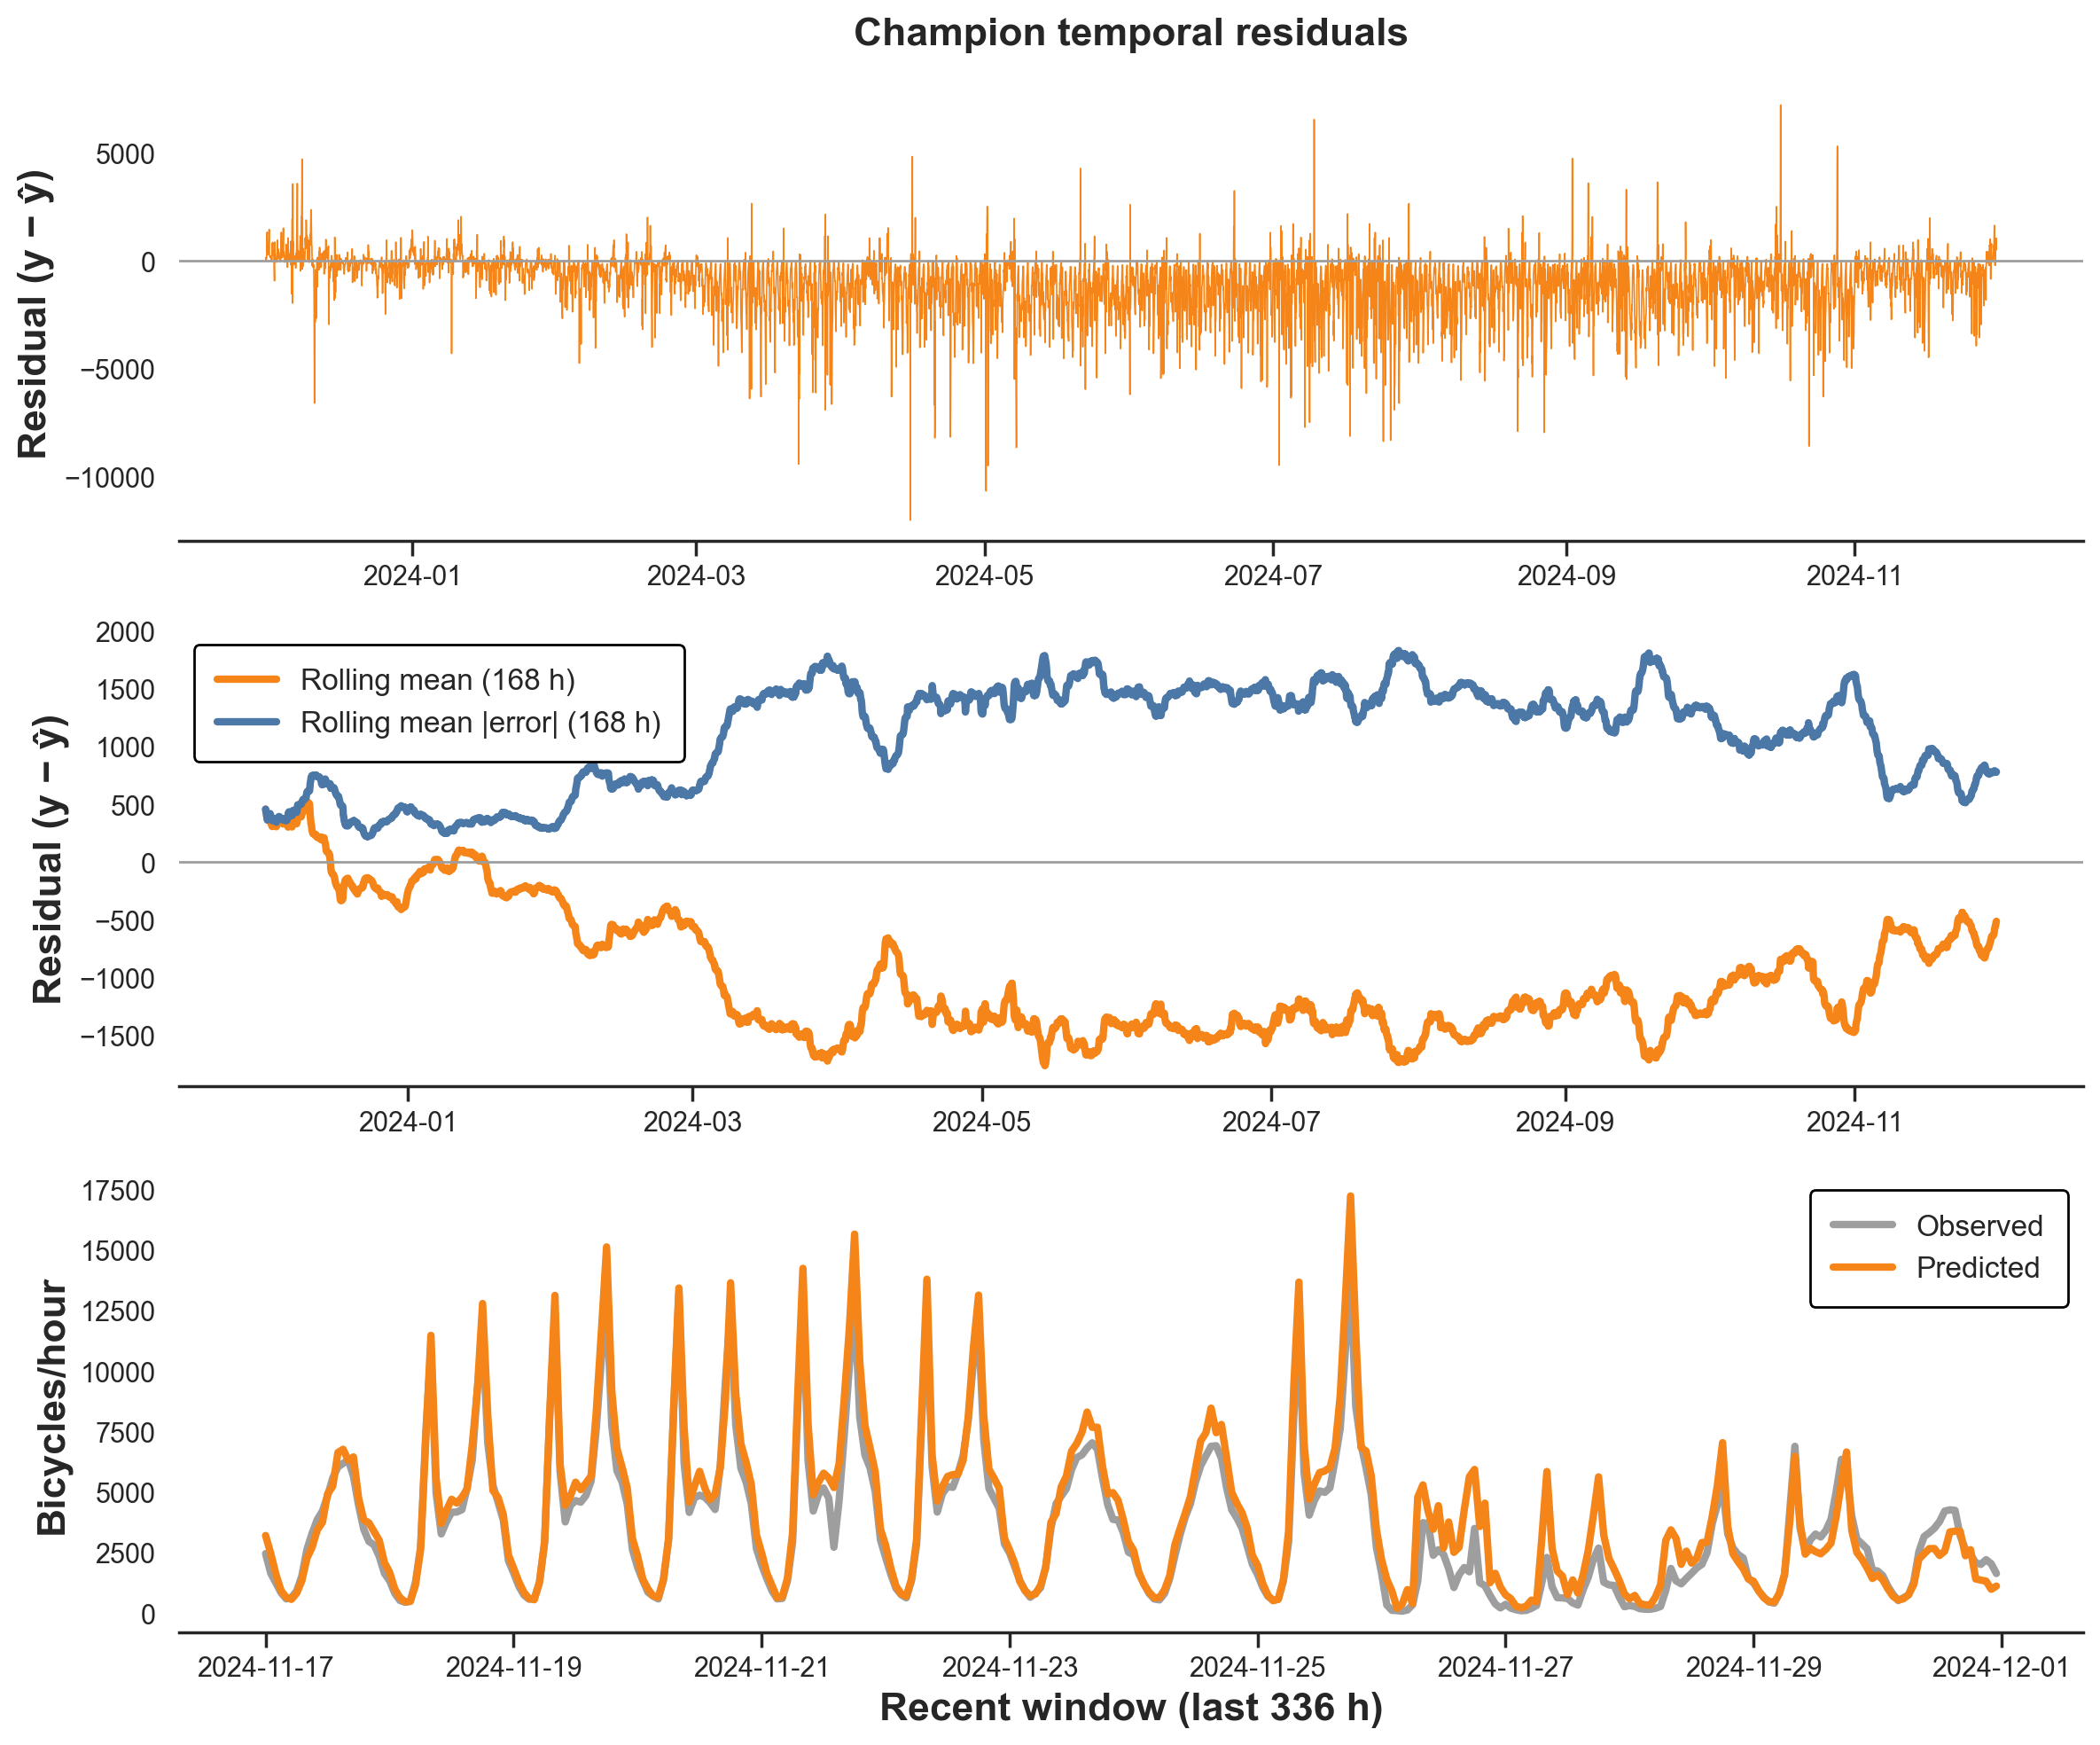

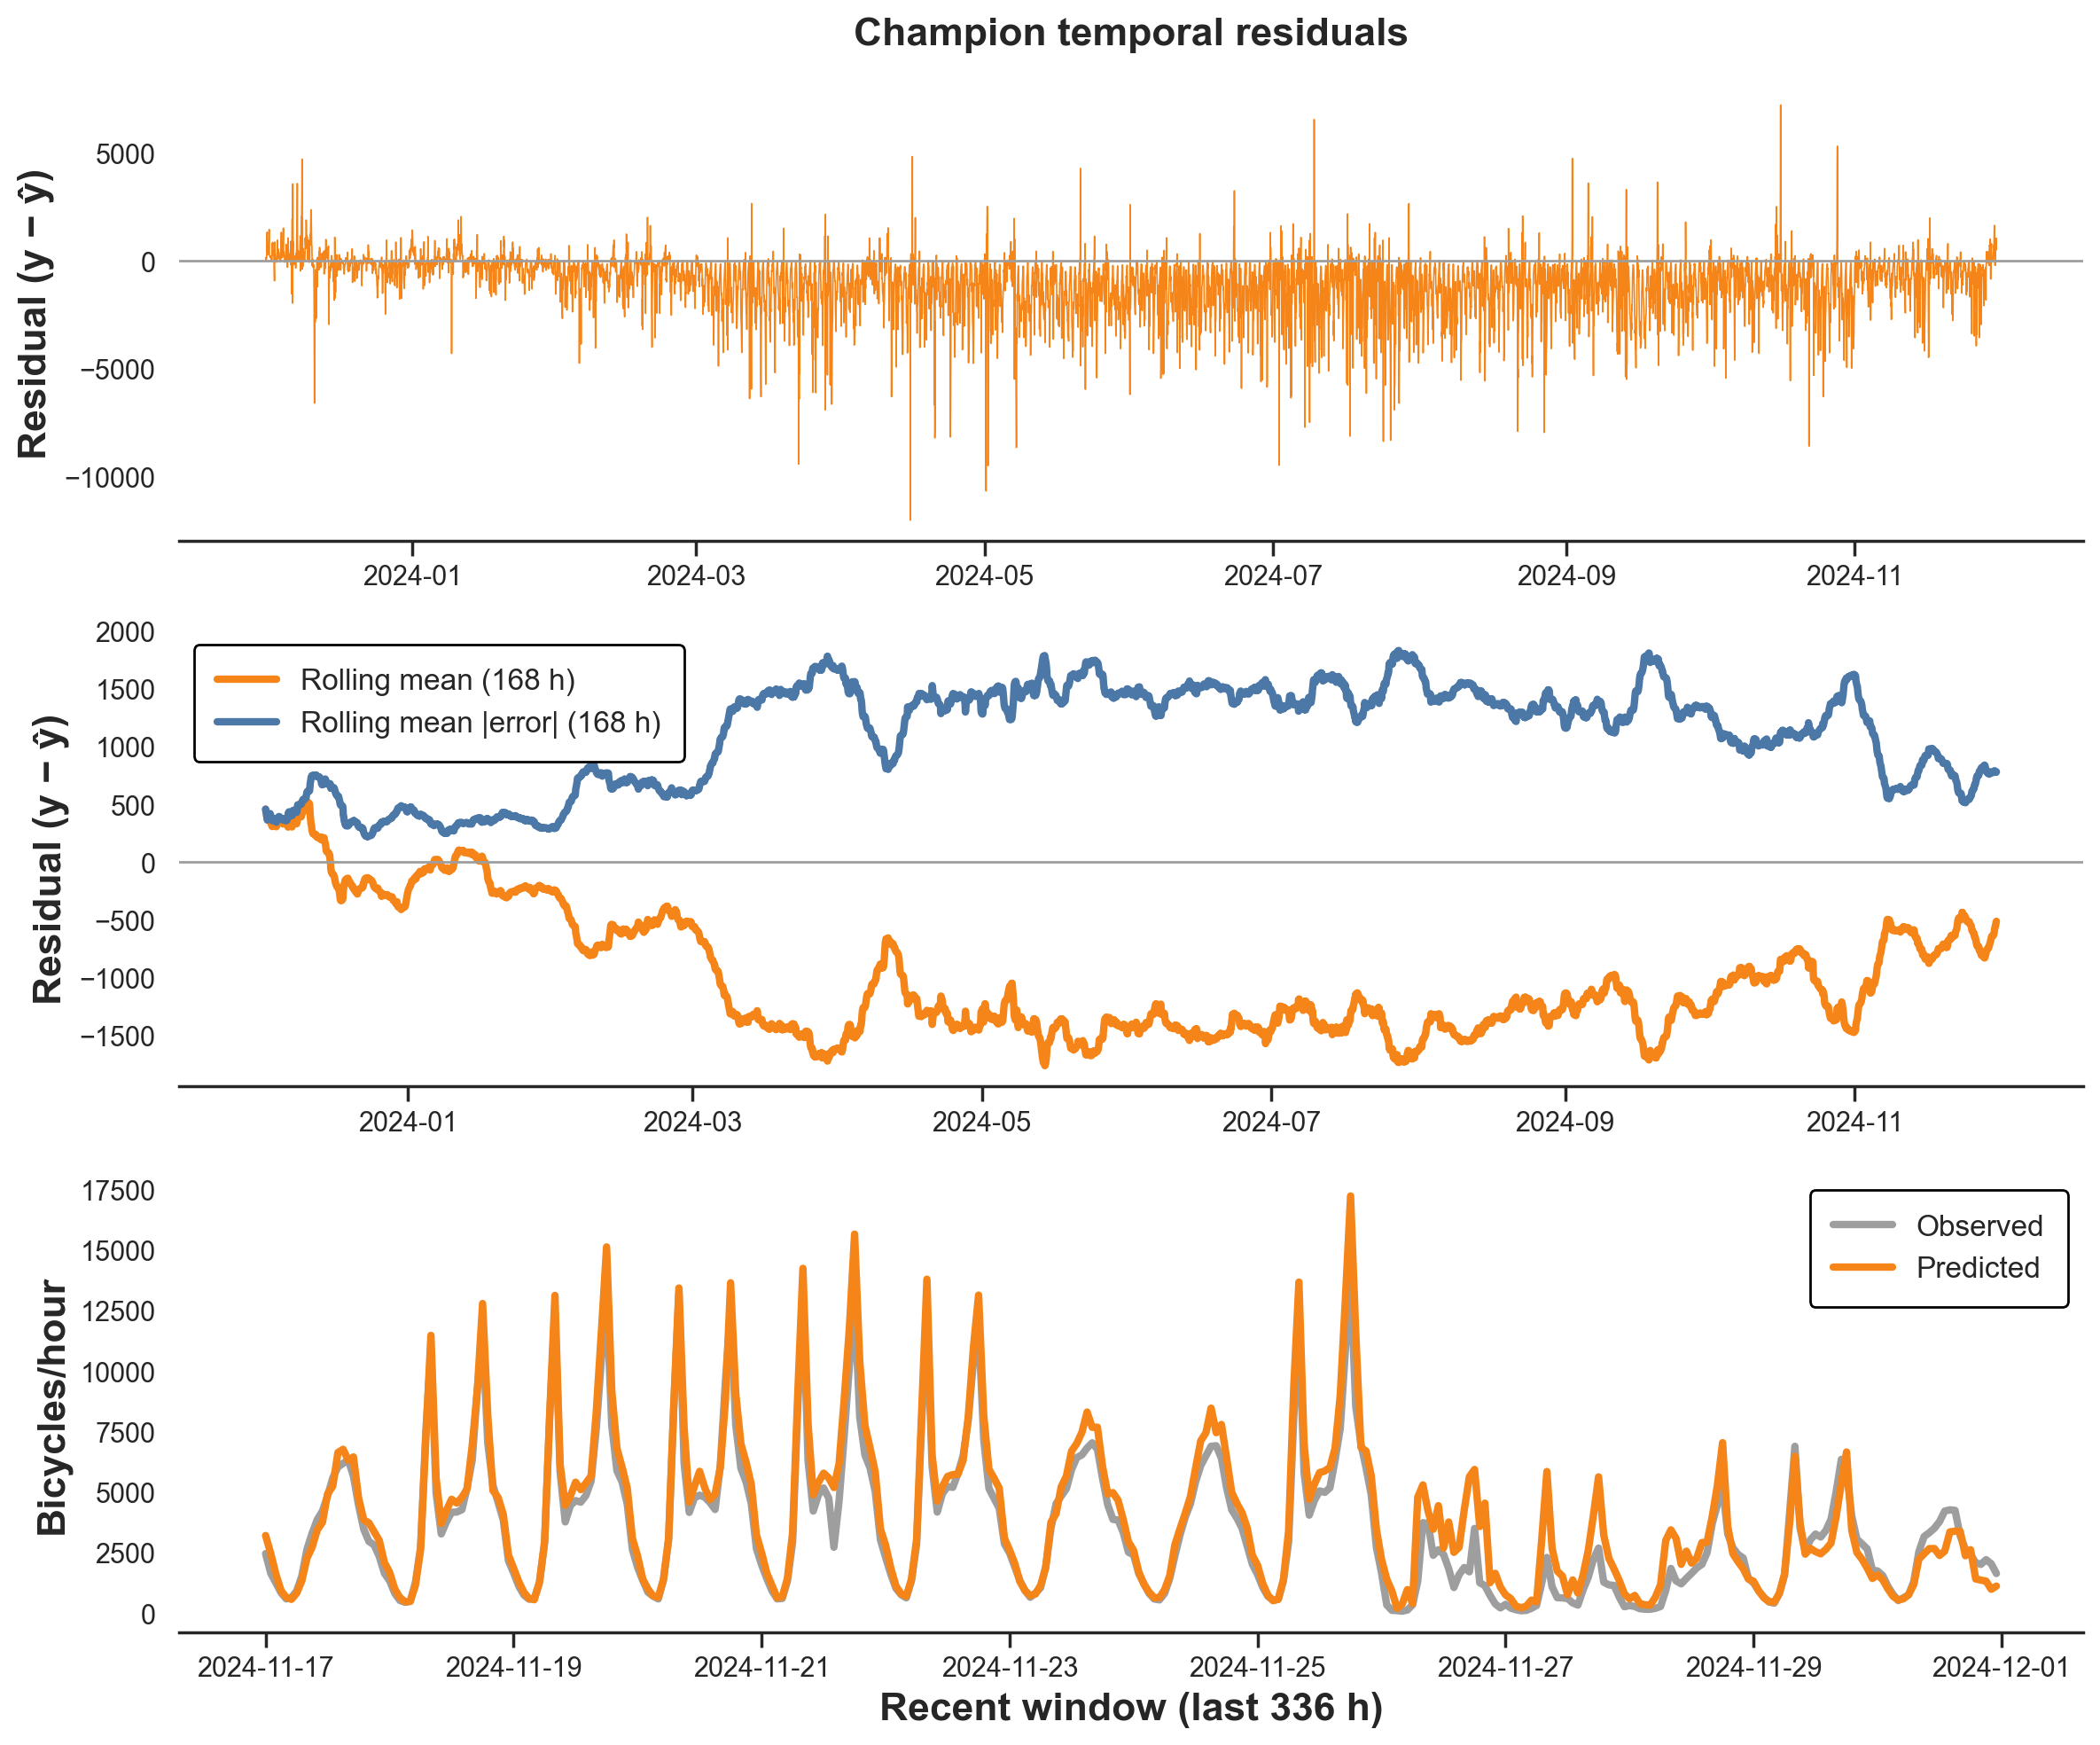

In [13]:
reports.plot_temporal_residuals(results, lang=lang)

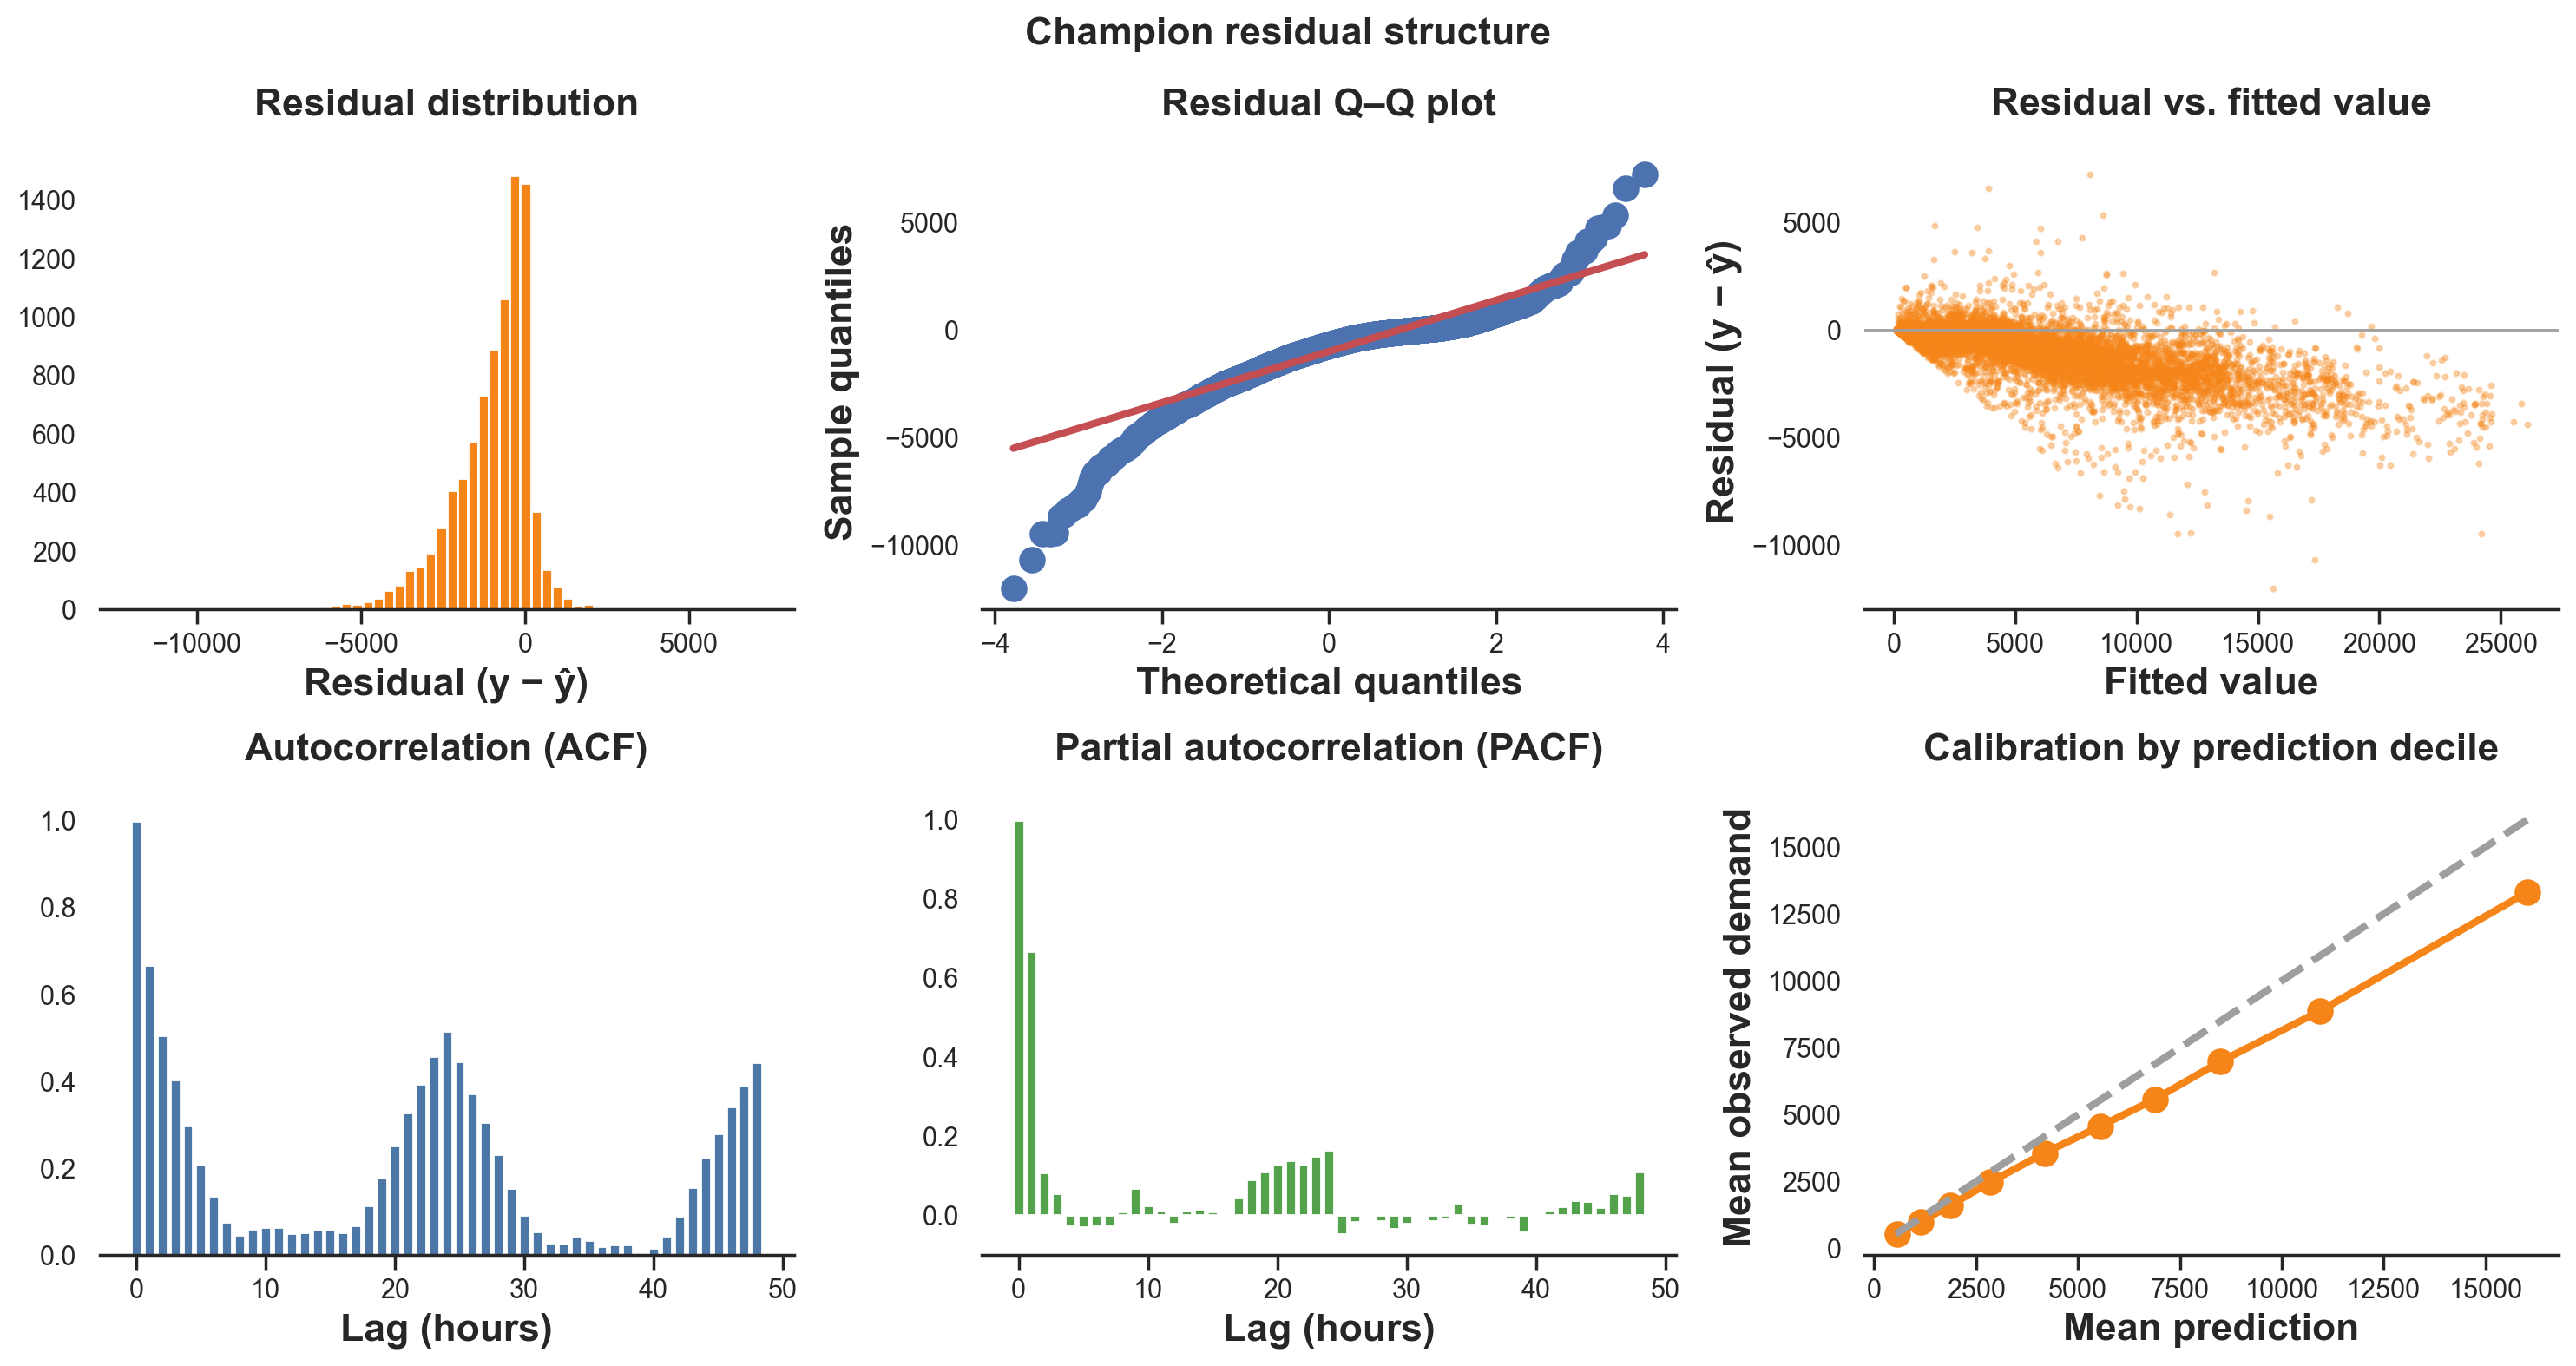

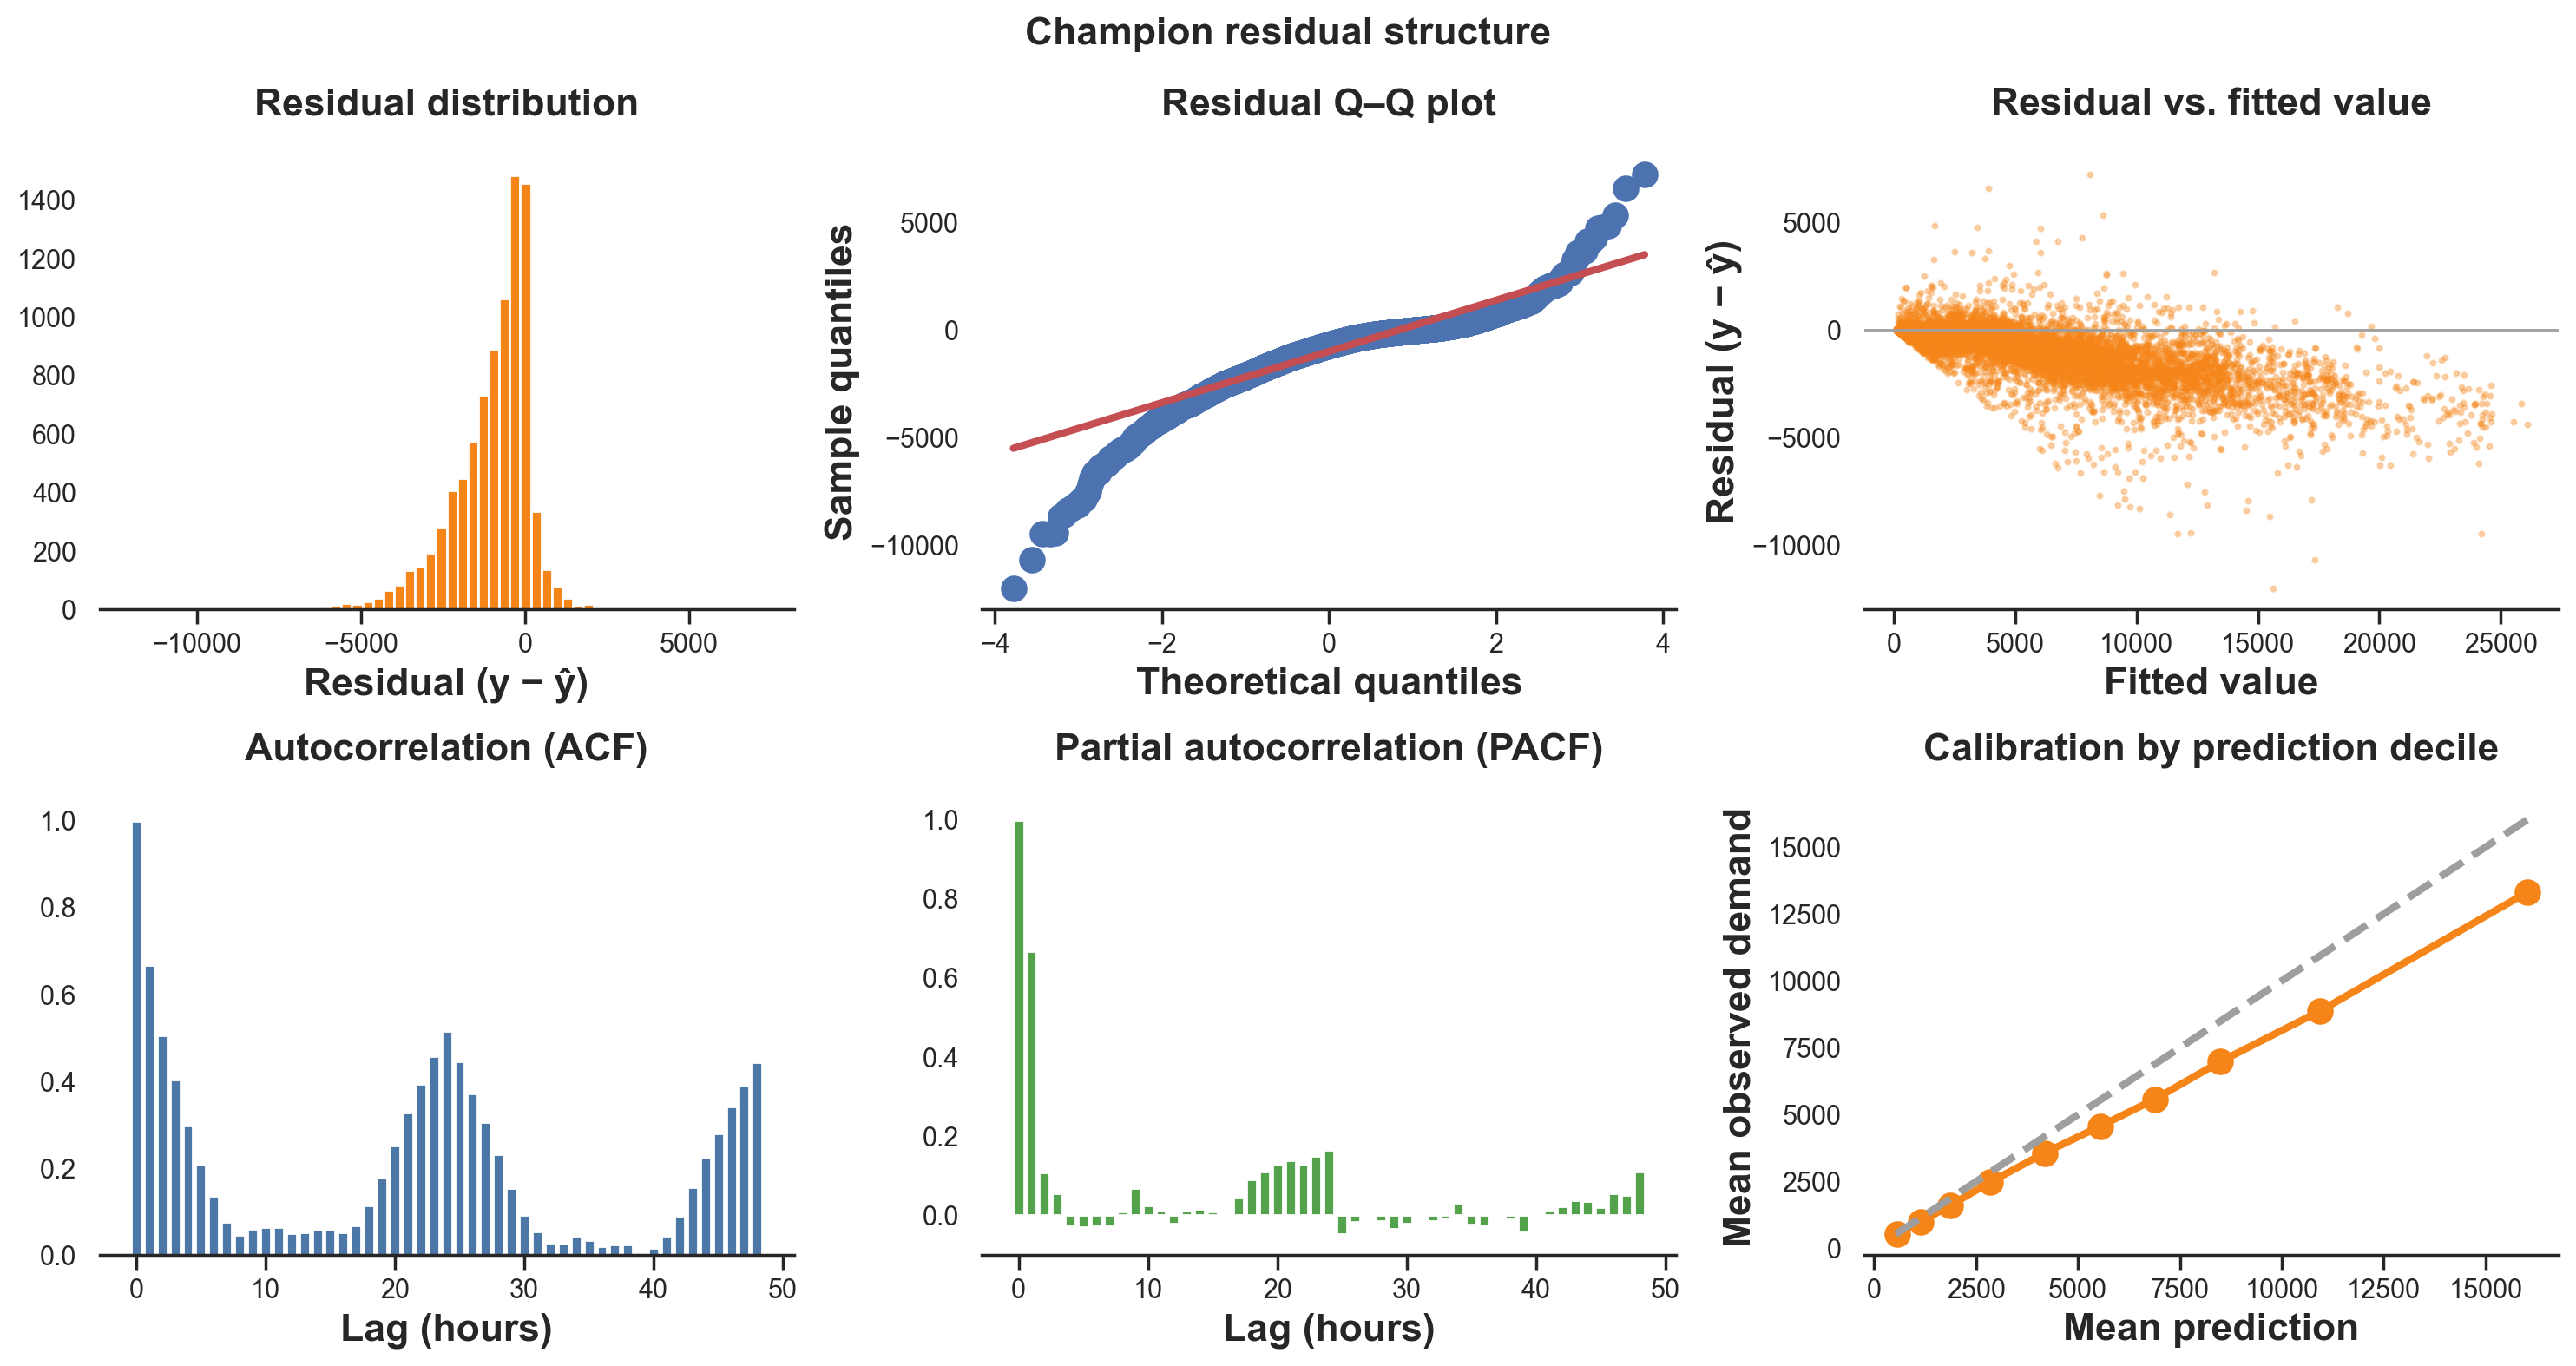

In [14]:
reports.plot_residual_structure(results, lang=lang)

### 7.1 Screening the Residual Mean and Error Scale

A post-holdout screening is added as a diagnostic reading of the confirmed Champion. Bias is measured as ŷ − y, whereas the observation-level residual remains y − ŷ. This separation makes it possible to assess whether the error is primarily shifted in its mean, whether the error scale increases with the predicted level, and whether error peaks are concentrated in specific calendar periods.

Profiles by month, hour, season, and prediction decile are computed exclusively from the predictions and residuals already persisted in `FinalValidationResults`. No pipeline is refitted, no new prediction is requested, and no additional meteorological variable is reopened from the raw dataset.


In [15]:
reports.residual_triage_report(results, lang=lang)


,Estimator,ARCH lag,MAE,Mean bias (ŷ-y),|bias| / MAE,Durbin–Watson,Autocorr. lag 1,Autocorr. lag 24,Autocorr. lag 168,Residual-standard-deviation ratio by predicted level,MAE ratio by predicted level,Original ARCH,Standardized ARCH,ARCH reduction after standardization,Original ARCH/n,Standardized ARCH/n,ARCH persists after standardization,Diagnostic use
0,CatBoostRegressor,24,1118.087076,1000.094704,0.894469,0.40716,0.66726,0.515381,0.452973,5.711271,17.626275,2577.201592,1336.574975,0.481385,0.294201,0.152577,Yes,Yes
1,CatBoostRegressor,168,1118.087076,1000.094704,0.894469,0.40716,0.66726,0.515381,0.452973,5.711271,17.626275,3050.499624,1570.027051,0.485321,0.354051,0.182222,Yes,Yes


In [16]:
reports.residual_profile_report(results, 'month', lang=lang)


,Dimension,Segment,Observations,Mean observed demand,Mean prediction,Mean bias (ŷ-y),Mean residual (y-ŷ),MAE,RMSE,Residual standard deviation,Overestimation share,Underestimation share
0,month,Yes,744,2601.338710,2734.708598,133.369888,-133.369888,340.955941,509.741176,492.315256,0.610215,0.389785
1,month,2,696,2844.652299,3462.332269,617.679970,-617.679970,698.750568,972.159839,751.250353,0.841954,0.158046
2,month,3,744,4131.861559,5533.581785,1401.720226,-1401.720226,1437.066244,1930.167782,1327.816942,0.966398,0.033602
3,month,4,720,6257.427778,7456.854813,1199.427035,-1199.427035,1265.286892,1754.739712,1281.705062,0.933333,0.066667
4,month,5,744,6304.350806,7791.453639,1487.102832,-1487.102832,1568.377730,2033.148263,1387.373103,0.935484,0.064516
5,month,6,720,6607.769444,8020.898554,1413.129110,-1413.129110,1444.458126,1846.586480,1189.501116,0.977778,0.022222
6,month,7,744,4878.625000,6295.989193,1417.364193,-1417.364193,1523.976263,2143.472123,1609.046727,0.909946,0.090054
7,month,8,744,5186.048387,6509.687947,1323.639560,-1323.639560,1355.192076,1797.943146,1217.608548,0.965054,0.034946
8,month,9,720,5758.645833,7052.397801,1293.751967,-1293.751967,1393.156942,1785.124232,1230.844632,0.919444,0.080556
9,month,10,744,6127.263441,7209.793199,1082.529758,-1082.529758,1209.456865,1640.421731,1233.352077,0.905914,0.094086


In [17]:
reports.residual_profile_report(results, 'hour', lang=lang)


,Dimension,Segment,Observations,Mean observed demand,Mean prediction,Mean bias (ŷ-y),Mean residual (y-ŷ),MAE,RMSE,Residual standard deviation,Overestimation share,Underestimation share
0,hour,No,366,2401.795082,2964.946224,563.151142,-563.151142,603.468610,736.020732,474.555179,0.879781,0.120219
1,hour,Yes,366,1655.409836,2043.618483,388.208647,-388.208647,430.336652,533.022633,365.749467,0.874317,0.125683
2,hour,2,366,1090.710383,1332.041295,241.330912,-241.330912,283.525752,355.023544,260.742908,0.857923,0.142077
3,hour,3,366,776.368852,902.128314,125.759462,-125.759462,164.806876,221.913570,183.089541,0.784153,0.215847
4,hour,4,366,656.147541,757.166977,101.019436,-101.019436,135.046081,181.013213,150.408335,0.770492,0.229508
5,hour,5,366,1185.986339,1326.551727,140.565389,-140.565389,188.307701,247.088288,203.487415,0.743169,0.256831
6,hour,6,366,2548.978142,2859.511041,310.532899,-310.532899,434.708154,608.894850,524.474808,0.792350,0.207650
7,hour,7,366,5956.748634,6784.267481,827.518847,-827.518847,1088.990901,1635.178838,1412.257685,0.800546,0.199454
8,hour,8,366,8499.598361,10107.489875,1607.891515,-1607.891515,1809.184979,2506.179870,1925.031795,0.860656,0.139344
9,hour,9,366,4960.945355,5888.444780,927.499425,-927.499425,1079.410867,1364.752690,1002.517199,0.866120,0.133880


In [18]:
reports.residual_profile_report(results, 'season', lang=lang)


,Dimension,Segment,Observations,Mean observed demand,Mean prediction,Mean bias (ŷ-y),Mean residual (y-ŷ),MAE,RMSE,Residual standard deviation,Overestimation share,Underestimation share
0,season,Autumn,2184,5536.924451,6525.872410,988.947960,-988.947960,1106.457775,1518.149521,1152.114435,0.879579,0.120421
1,season,Spring,2208,5557.015399,6921.540679,1364.525281,-1364.525281,1425.297500,1911.093953,1338.343032,0.945199,0.054801
2,season,Summer,2208,5546.064764,6930.466826,1384.402061,-1384.402061,1441.173503,1936.311179,1354.090961,0.950634,0.049366
3,season,Winter,2184,2736.059524,2990.335151,254.275627,-254.275627,492.493188,762.963155,719.509361,0.656593,0.343407


In [19]:
reports.residual_profile_report(results, 'predicted_demand_decile', lang=lang)


,Dimension,Segment,Observations,Mean observed demand,Mean prediction,Mean bias (ŷ-y),Mean residual (y-ŷ),MAE,RMSE,Residual standard deviation,Overestimation share,Underestimation share
0,predicted_demand_decile,D01,879,533.715586,560.272451,26.556865,-26.556865,155.287580,251.466522,250.202645,0.623436,0.376564
1,predicted_demand_decile,D02,878,988.556948,1141.545895,152.988947,-152.988947,269.618674,385.255806,353.778134,0.801822,0.198178
2,predicted_demand_decile,D03,878,1604.093394,1860.413359,256.319965,-256.319965,400.703656,563.757609,502.404419,0.804100,0.195900
3,predicted_demand_decile,D04,879,2482.529010,2854.031071,371.502061,-371.502061,571.216459,746.838395,648.252950,0.782708,0.217292
4,predicted_demand_decile,D05,878,3567.612756,4180.704400,613.091643,-613.091643,830.601879,1079.934015,889.537712,0.817768,0.182232
5,predicted_demand_decile,D06,878,4573.365604,5555.314706,981.949102,-981.949102,1103.773711,1336.477939,907.130900,0.922551,0.077449
6,predicted_demand_decile,D07,879,5573.597270,6882.108955,1308.511685,-1308.511685,1367.558331,1627.014150,967.490104,0.946530,0.053470
7,predicted_demand_decile,D08,878,6978.162870,8490.256831,1512.093961,-1512.093961,1630.995320,1935.459473,1208.817399,0.944191,0.055809
8,predicted_demand_decile,D09,878,8866.420273,10931.792042,2065.371769,-2065.371769,2113.564801,2439.727924,1299.397879,0.963554,0.036446
9,predicted_demand_decile,D10,879,13307.914676,16019.999325,2712.084650,-2712.084650,2737.141633,3065.134553,1428.975066,0.978385,0.021615


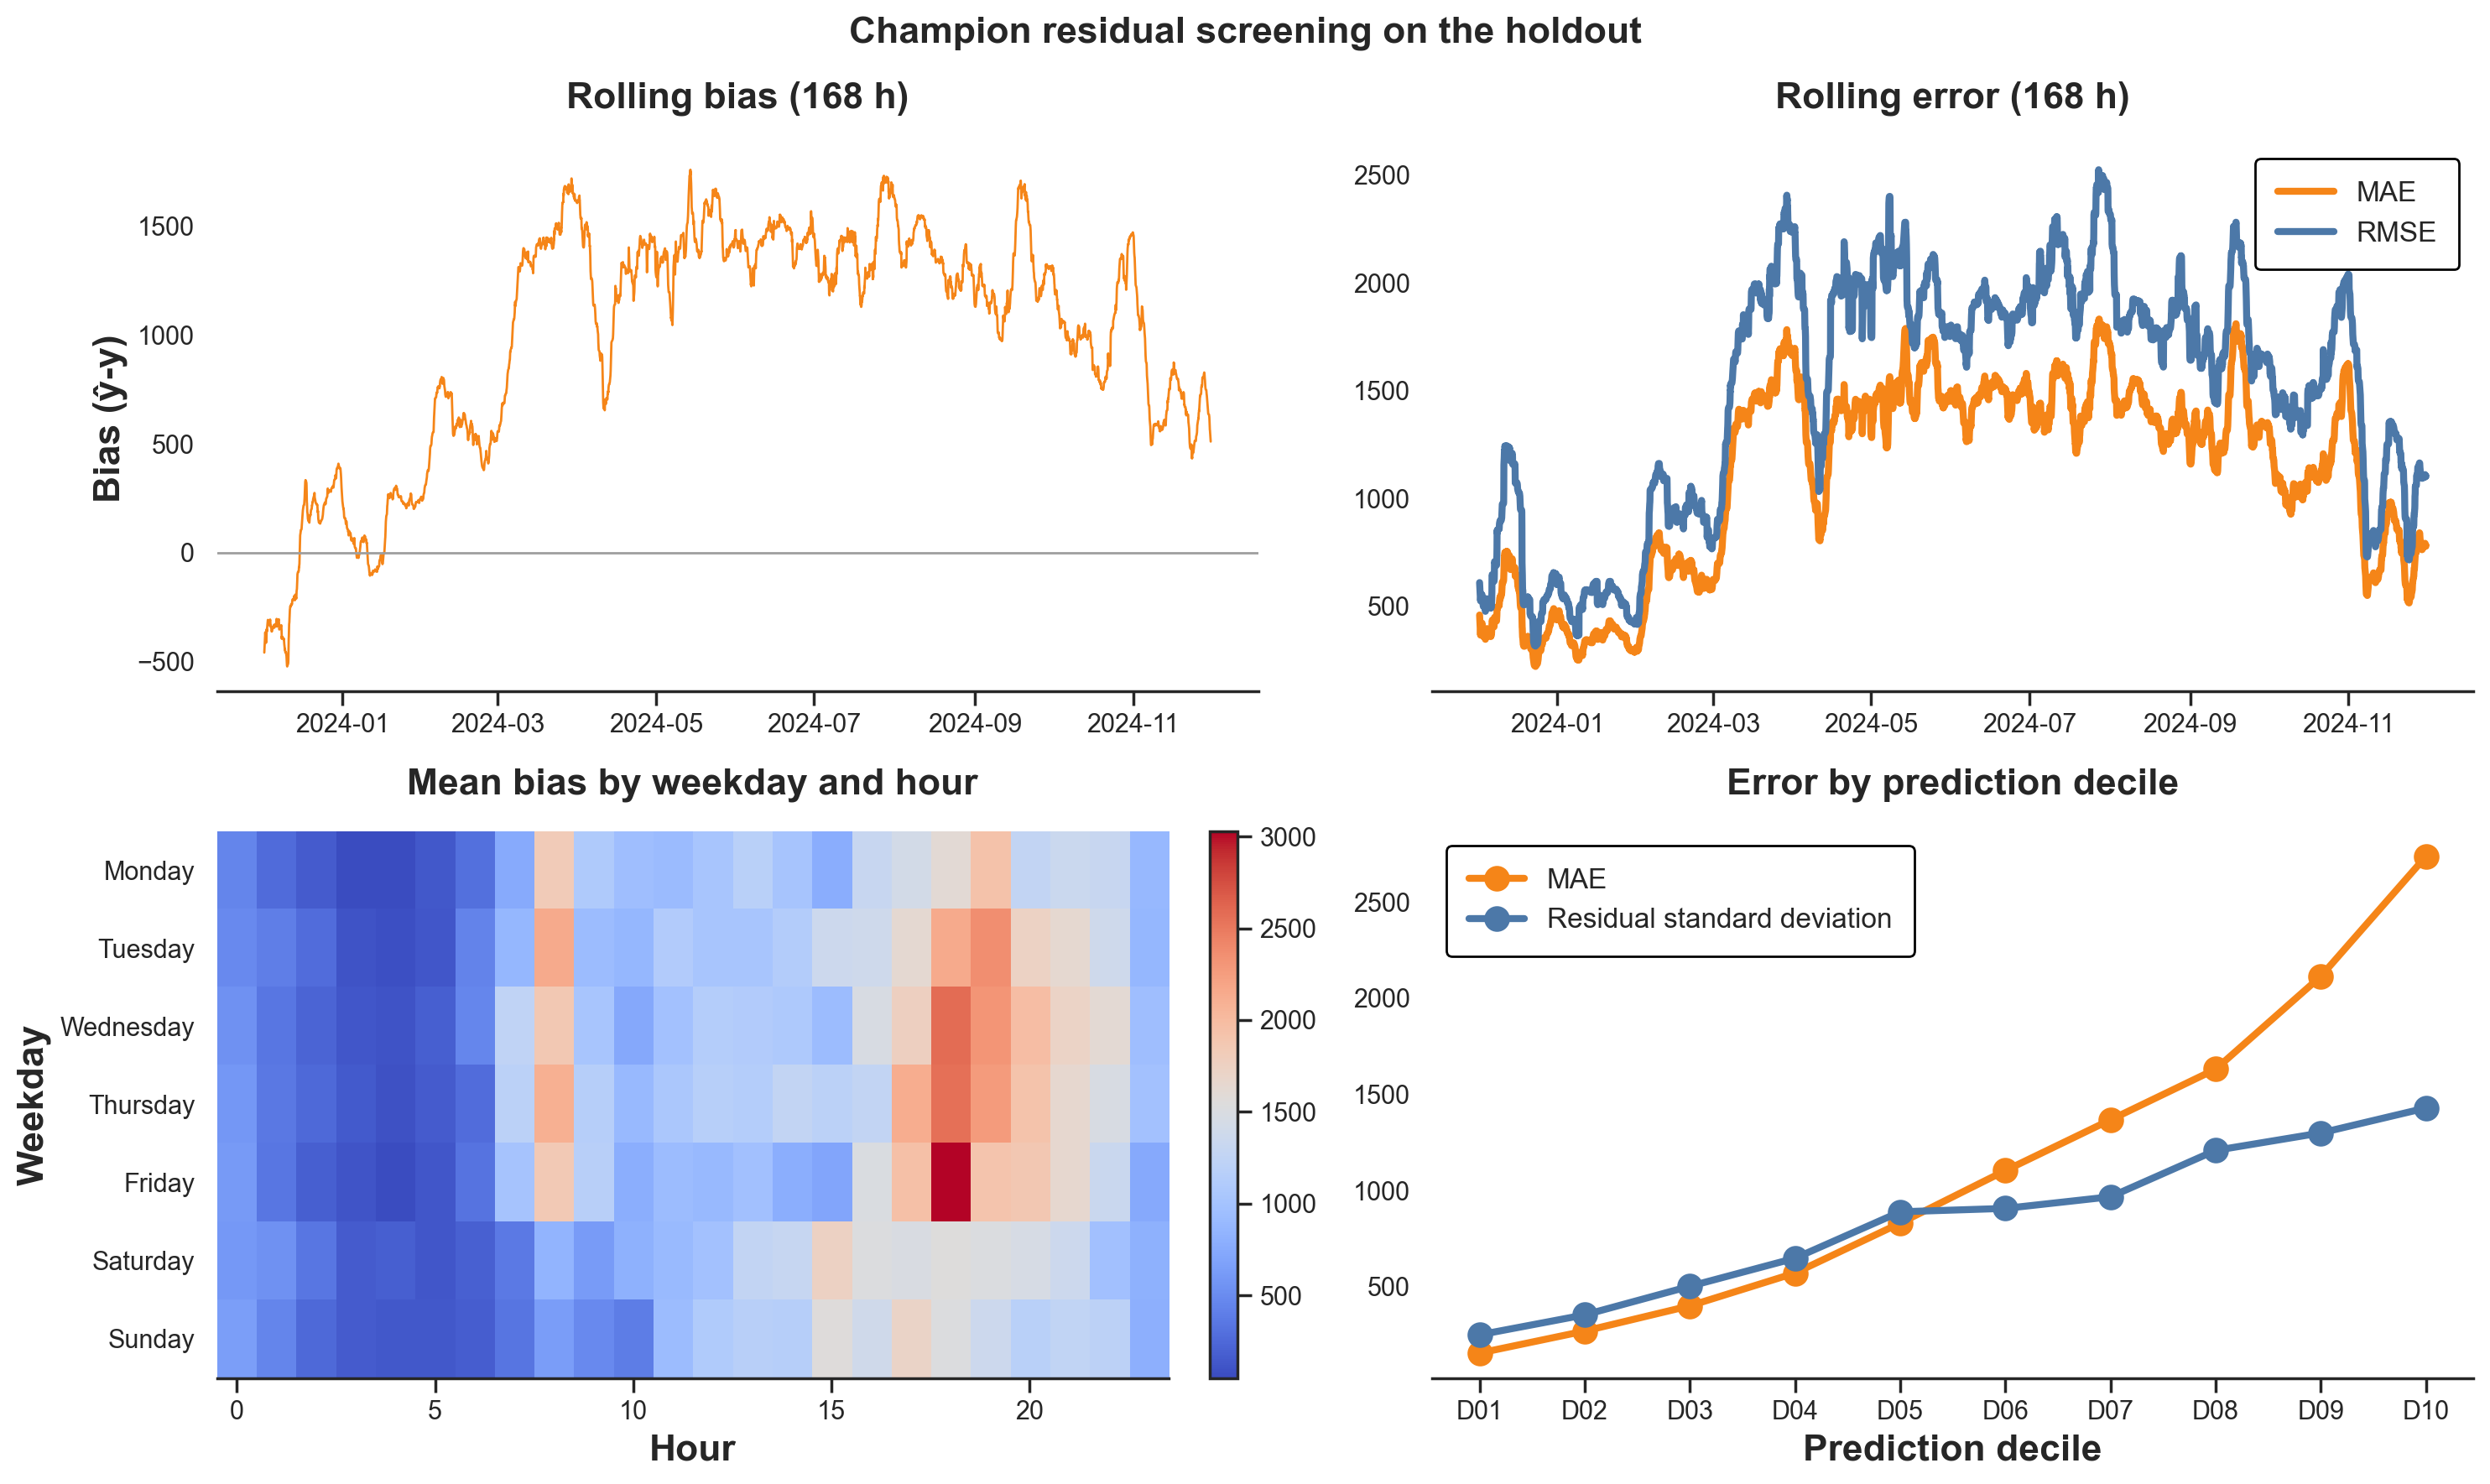

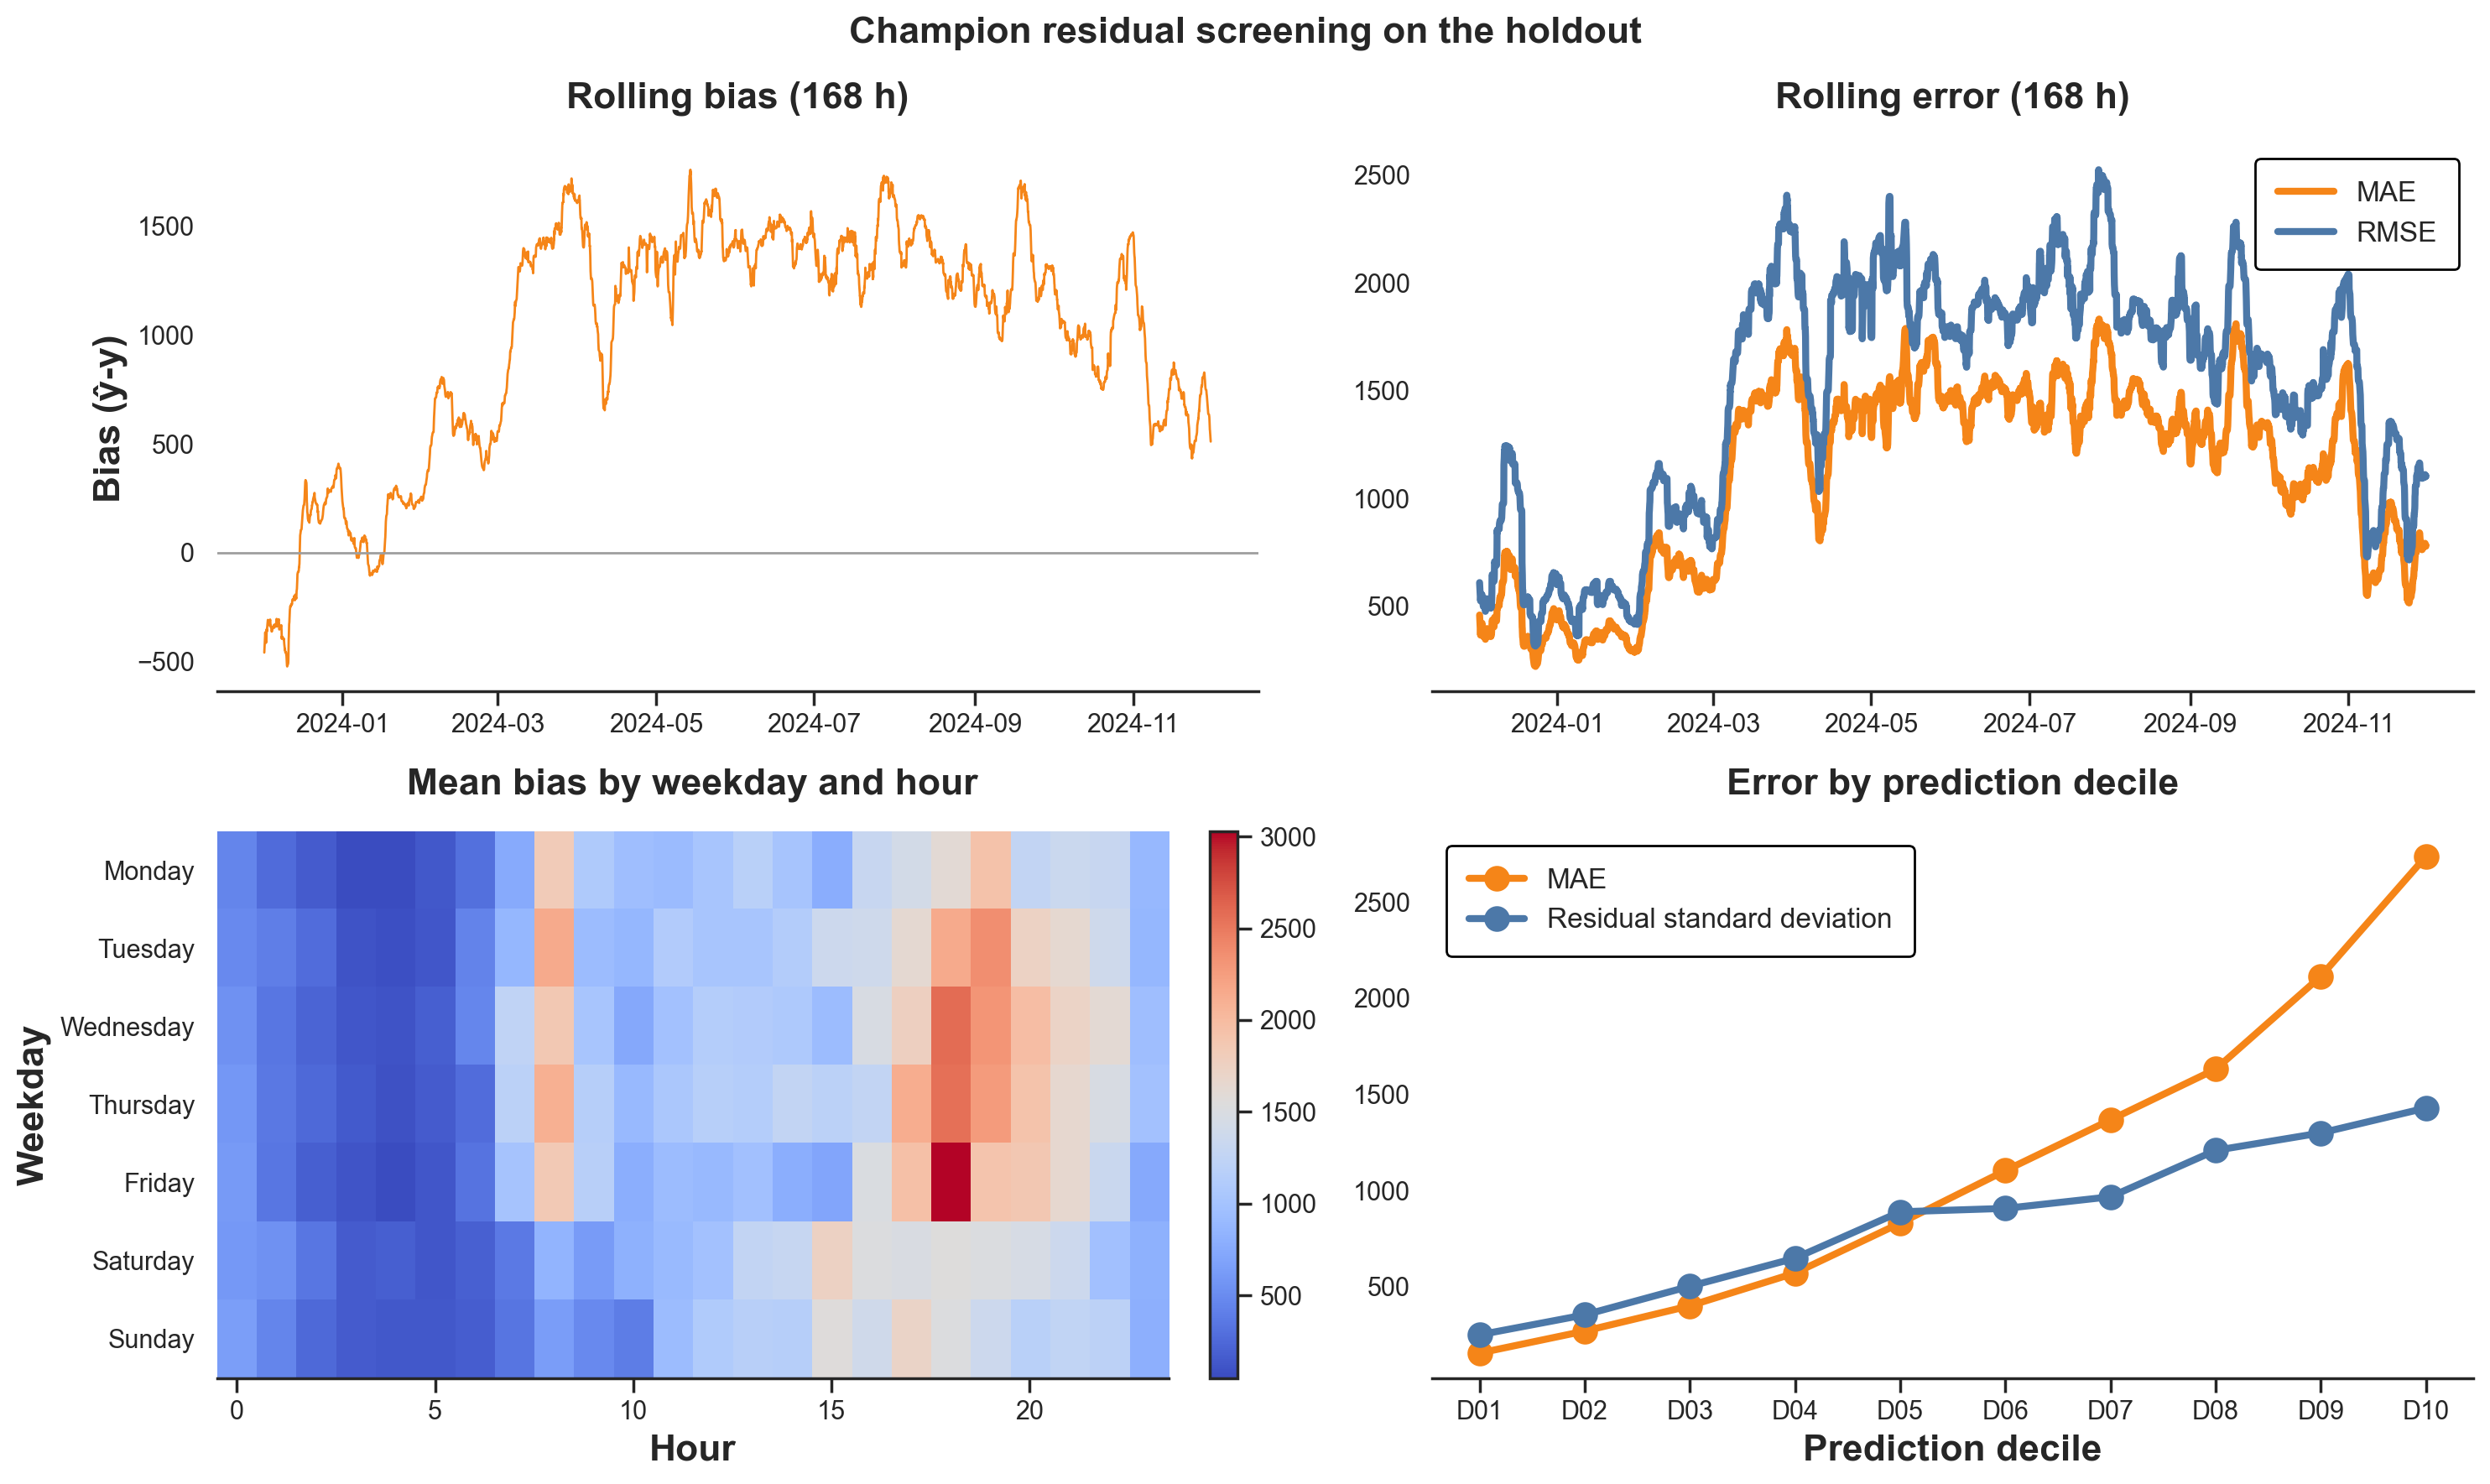

In [20]:
reports.plot_residual_triage(results, lang=lang)


### 7.2 Daily and Weekly Persistence after Standardization

Heteroscedasticity is examined through four versions of the residual. First, the original residual is retained as a reference. Next, the global residual mean is removed. The mean hour-of-week pattern is then removed so that daily and weekly persistence can be evaluated after calendar deseasonalization. Finally, the calendar-deseasonalized residual is divided by a descriptive residual scale estimated by season and prediction decile.

These transformations are estimated within the holdout itself and serve an exclusively descriptive purpose. They do not constitute a validated calibrator, cannot be added to the current model, and do not reorder the Champion and Challengers. Reductions in ARCH statistics and squared-residual autocorrelations are interpreted relative to the original residual; the problem is not declared solved merely because a p-value increases.


In [21]:
reports.residual_transformation_report(results, lang=lang)


,Residual version,ARCH lag,Observations,Effective observations,Mean,Standard deviation,Durbin–Watson,ACF lag 1,ACF lag 24,ACF lag 168,...,Adjusted p-value (Holm),ARCH evidence,ARCH reduction vs. original,ACF lag-24 reduction,ACF lag-168 reduction,Squared-ACF lag-24 reduction,Squared-ACF lag-168 reduction,Status,Reason,Diagnostic note
0,Original,24,8784,8760,-1.000095e+03,1256.294481,0.407160,0.667260,0.515381,0.452973,...,below numerical precision,Yes,0.000000,0.000000,0.000000e+00,0.000000,0.000000,Applicable,,Holdout-only descriptive transformation; not a...
1,Original,168,8784,8616,-1.000095e+03,1256.294481,0.407160,0.667260,0.515381,0.452973,...,below numerical precision,Yes,0.000000,0.000000,0.000000e+00,0.000000,0.000000,Applicable,,Holdout-only descriptive transformation; not a...
2,Globally debiased,24,8784,8760,-1.391577e-13,1256.294481,0.665216,0.667260,0.515381,0.452973,...,8.17e-309,Yes,0.405827,0.000000,1.110223e-16,0.416921,0.451940,Applicable,,Holdout-only descriptive transformation; not a...
3,Globally debiased,168,8784,8616,-1.391577e-13,1256.294481,0.665216,0.667260,0.515381,0.452973,...,2.42e-296,Yes,0.367843,0.000000,1.110223e-16,0.416921,0.451940,Applicable,,Holdout-only descriptive transformation; not a...
4,Without the mean weekly pattern,24,8784,8760,-9.939833e-15,1086.891194,0.765355,0.617208,0.387092,0.263973,...,2.12e-263,Yes,0.488252,0.248921,4.172448e-01,0.531308,0.601460,Applicable,,Holdout-only descriptive transformation; not a...
5,Without the mean weekly pattern,168,8784,8616,-9.939833e-15,1086.891194,0.765355,0.617208,0.387092,0.263973,...,2.08e-232,Yes,0.474393,0.248921,4.172448e-01,0.531308,0.601460,Applicable,,Holdout-only descriptive transformation; not a...
6,Standardized by predicted level,24,8784,8760,6.202107e-02,0.998402,0.849074,0.573520,0.316571,0.215960,...,3.53e-267,Yes,0.481385,0.385754,5.232383e-01,0.702704,0.691323,Applicable,,Holdout-only descriptive transformation; not a...
7,Standardized by predicted level,168,8784,8616,6.202107e-02,0.998402,0.849074,0.573520,0.316571,0.215960,...,6.31e-226,Yes,0.485321,0.385754,5.232383e-01,0.702704,0.691323,Applicable,,Holdout-only descriptive transformation; not a...


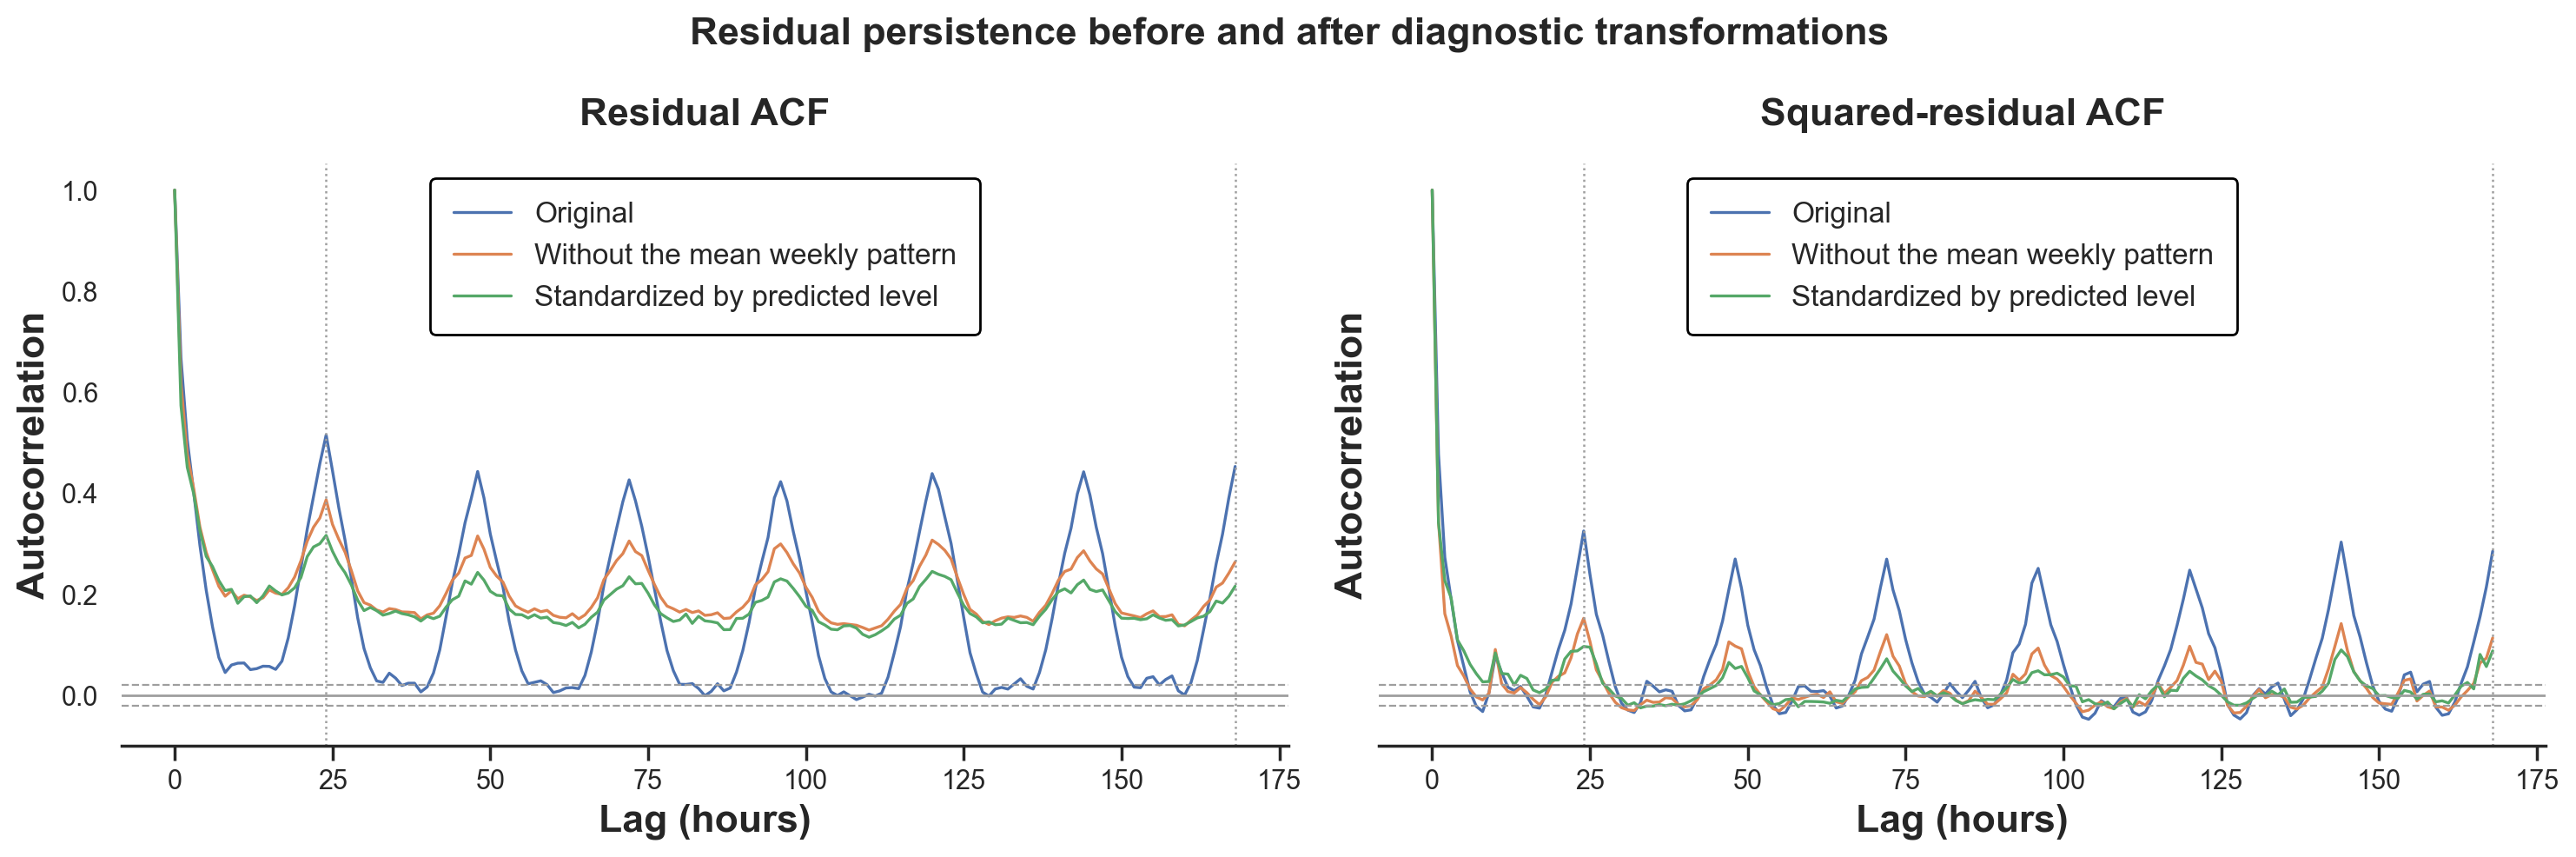

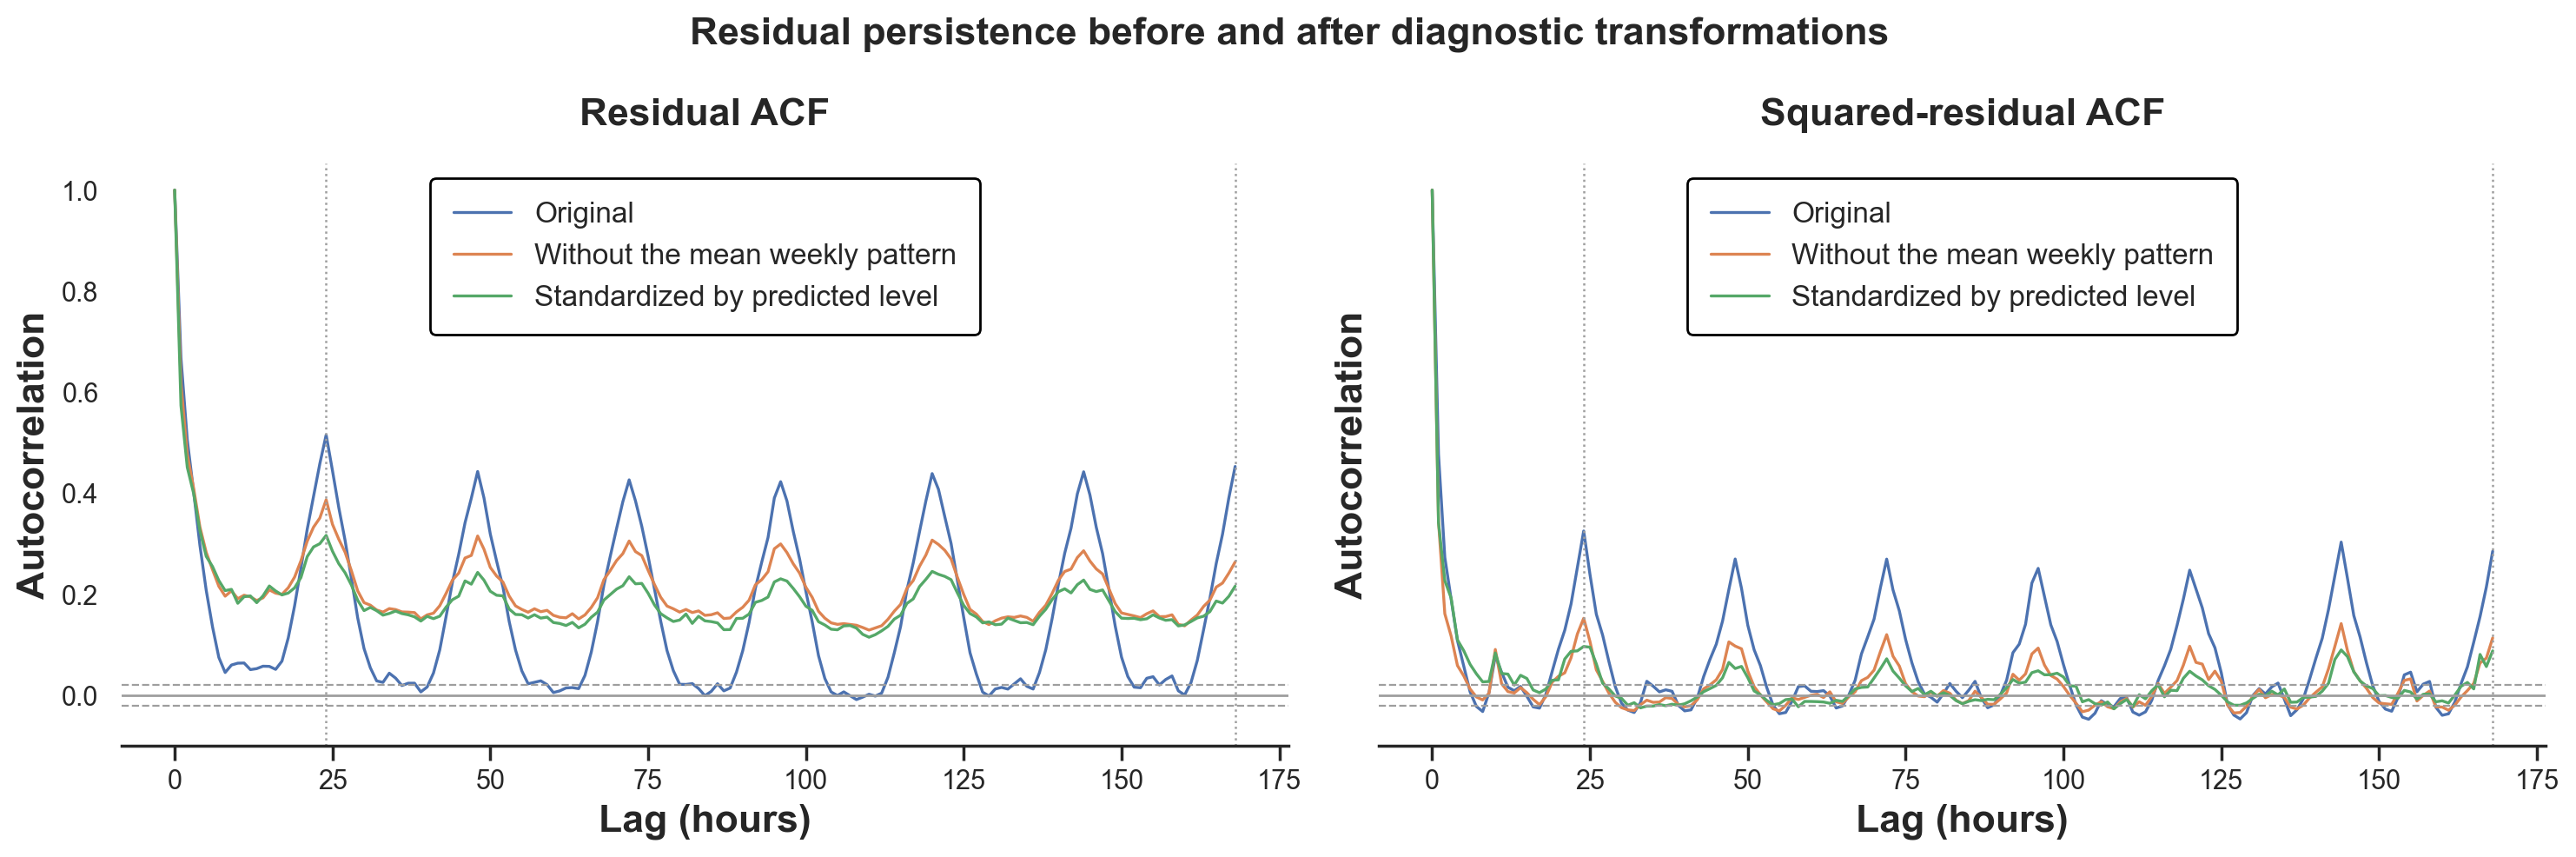

In [22]:
reports.plot_residual_transformation_acf(results, lang=lang)


In [23]:
reports.residual_handoff_message(results, lang=lang)


'Residual screening indicates a predominant shift toward overestimation; |bias| represents 89.4% of the Champion MAE. After removal of the mean weekly pattern, lag-168 autocorrelation was reduced by 41.7%; after standardization by predicted level, the mean ARCH indicator was reduced by 48.3%, but evidence of conditional clustering remained. CatBoost remains confirmed only as the best point predictor under the current protocol; intervals under the IID assumption have not yet been validated.'

> ### Insight
>
> CatBoost’s confirmation as the best point predictor is not revoked by residual heteroscedasticity. The evidence indicates that the error scale varies with the predicted level and that residuals remain temporally dependent. The confirmatory ranking is therefore retained, while the probabilistic interpretation of errors must still be treated cautiously.
>
> Bias and autocorrelation in the residual mean should be addressed before ARCH/GARCH is adopted. Prediction intervals under an IID assumption are not considered reliable at this stage, and lags or moving averages may be evaluated in a future version only when their availability is compatible with the prediction horizon and leakage is prevented. Any such version should be validated through development backtesting and subsequently confirmed in a new independent window.


## 8. Residuals by Operating Condition

Metrics are segmented by season, month, hour, weekday or weekend, holiday, functioning day, rush period, temperature band, extreme cold, extreme heat, and observed-demand quantile. Previously fragile conditions receive explicit attention, particularly autumn, extreme heat, and high-demand periods, where large underestimations were observed in earlier stages. Segment counts are preserved so that no observation is discarded or counted twice.


In [24]:
reports.condition_metrics_report(results, 'season', lang=lang)

,Segment,Estimator,Role,Observations,MAE,RMSE,WAPE,Mean bias (ŷ−y)
0,Winter,CatBoostRegressor,Champion,2184,492.493188,762.963155,0.180001,254.275627
1,Spring,CatBoostRegressor,Champion,2208,1425.297500,1911.093953,0.256486,1364.525281
2,Summer,CatBoostRegressor,Champion,2208,1441.173503,1936.311179,0.259855,1384.402061
3,Autumn,CatBoostRegressor,Champion,2184,1106.457775,1518.149521,0.199833,988.947960
4,Winter,HistGradientBoostingRegressor,Challenger,2184,559.039204,822.359664,0.204323,265.352071
5,Spring,HistGradientBoostingRegressor,Challenger,2208,1212.083966,1736.793195,0.218118,1113.750257
6,Summer,HistGradientBoostingRegressor,Challenger,2208,2302.996648,2953.085896,0.415249,2224.533430
7,Autumn,HistGradientBoostingRegressor,Challenger,2184,1617.996211,2164.874219,0.292219,1503.402362
8,Winter,RandomForestRegressor,Challenger,2184,668.590948,929.485656,0.244363,431.257205
9,Spring,RandomForestRegressor,Challenger,2208,1530.590787,2238.929349,0.275434,1370.380379


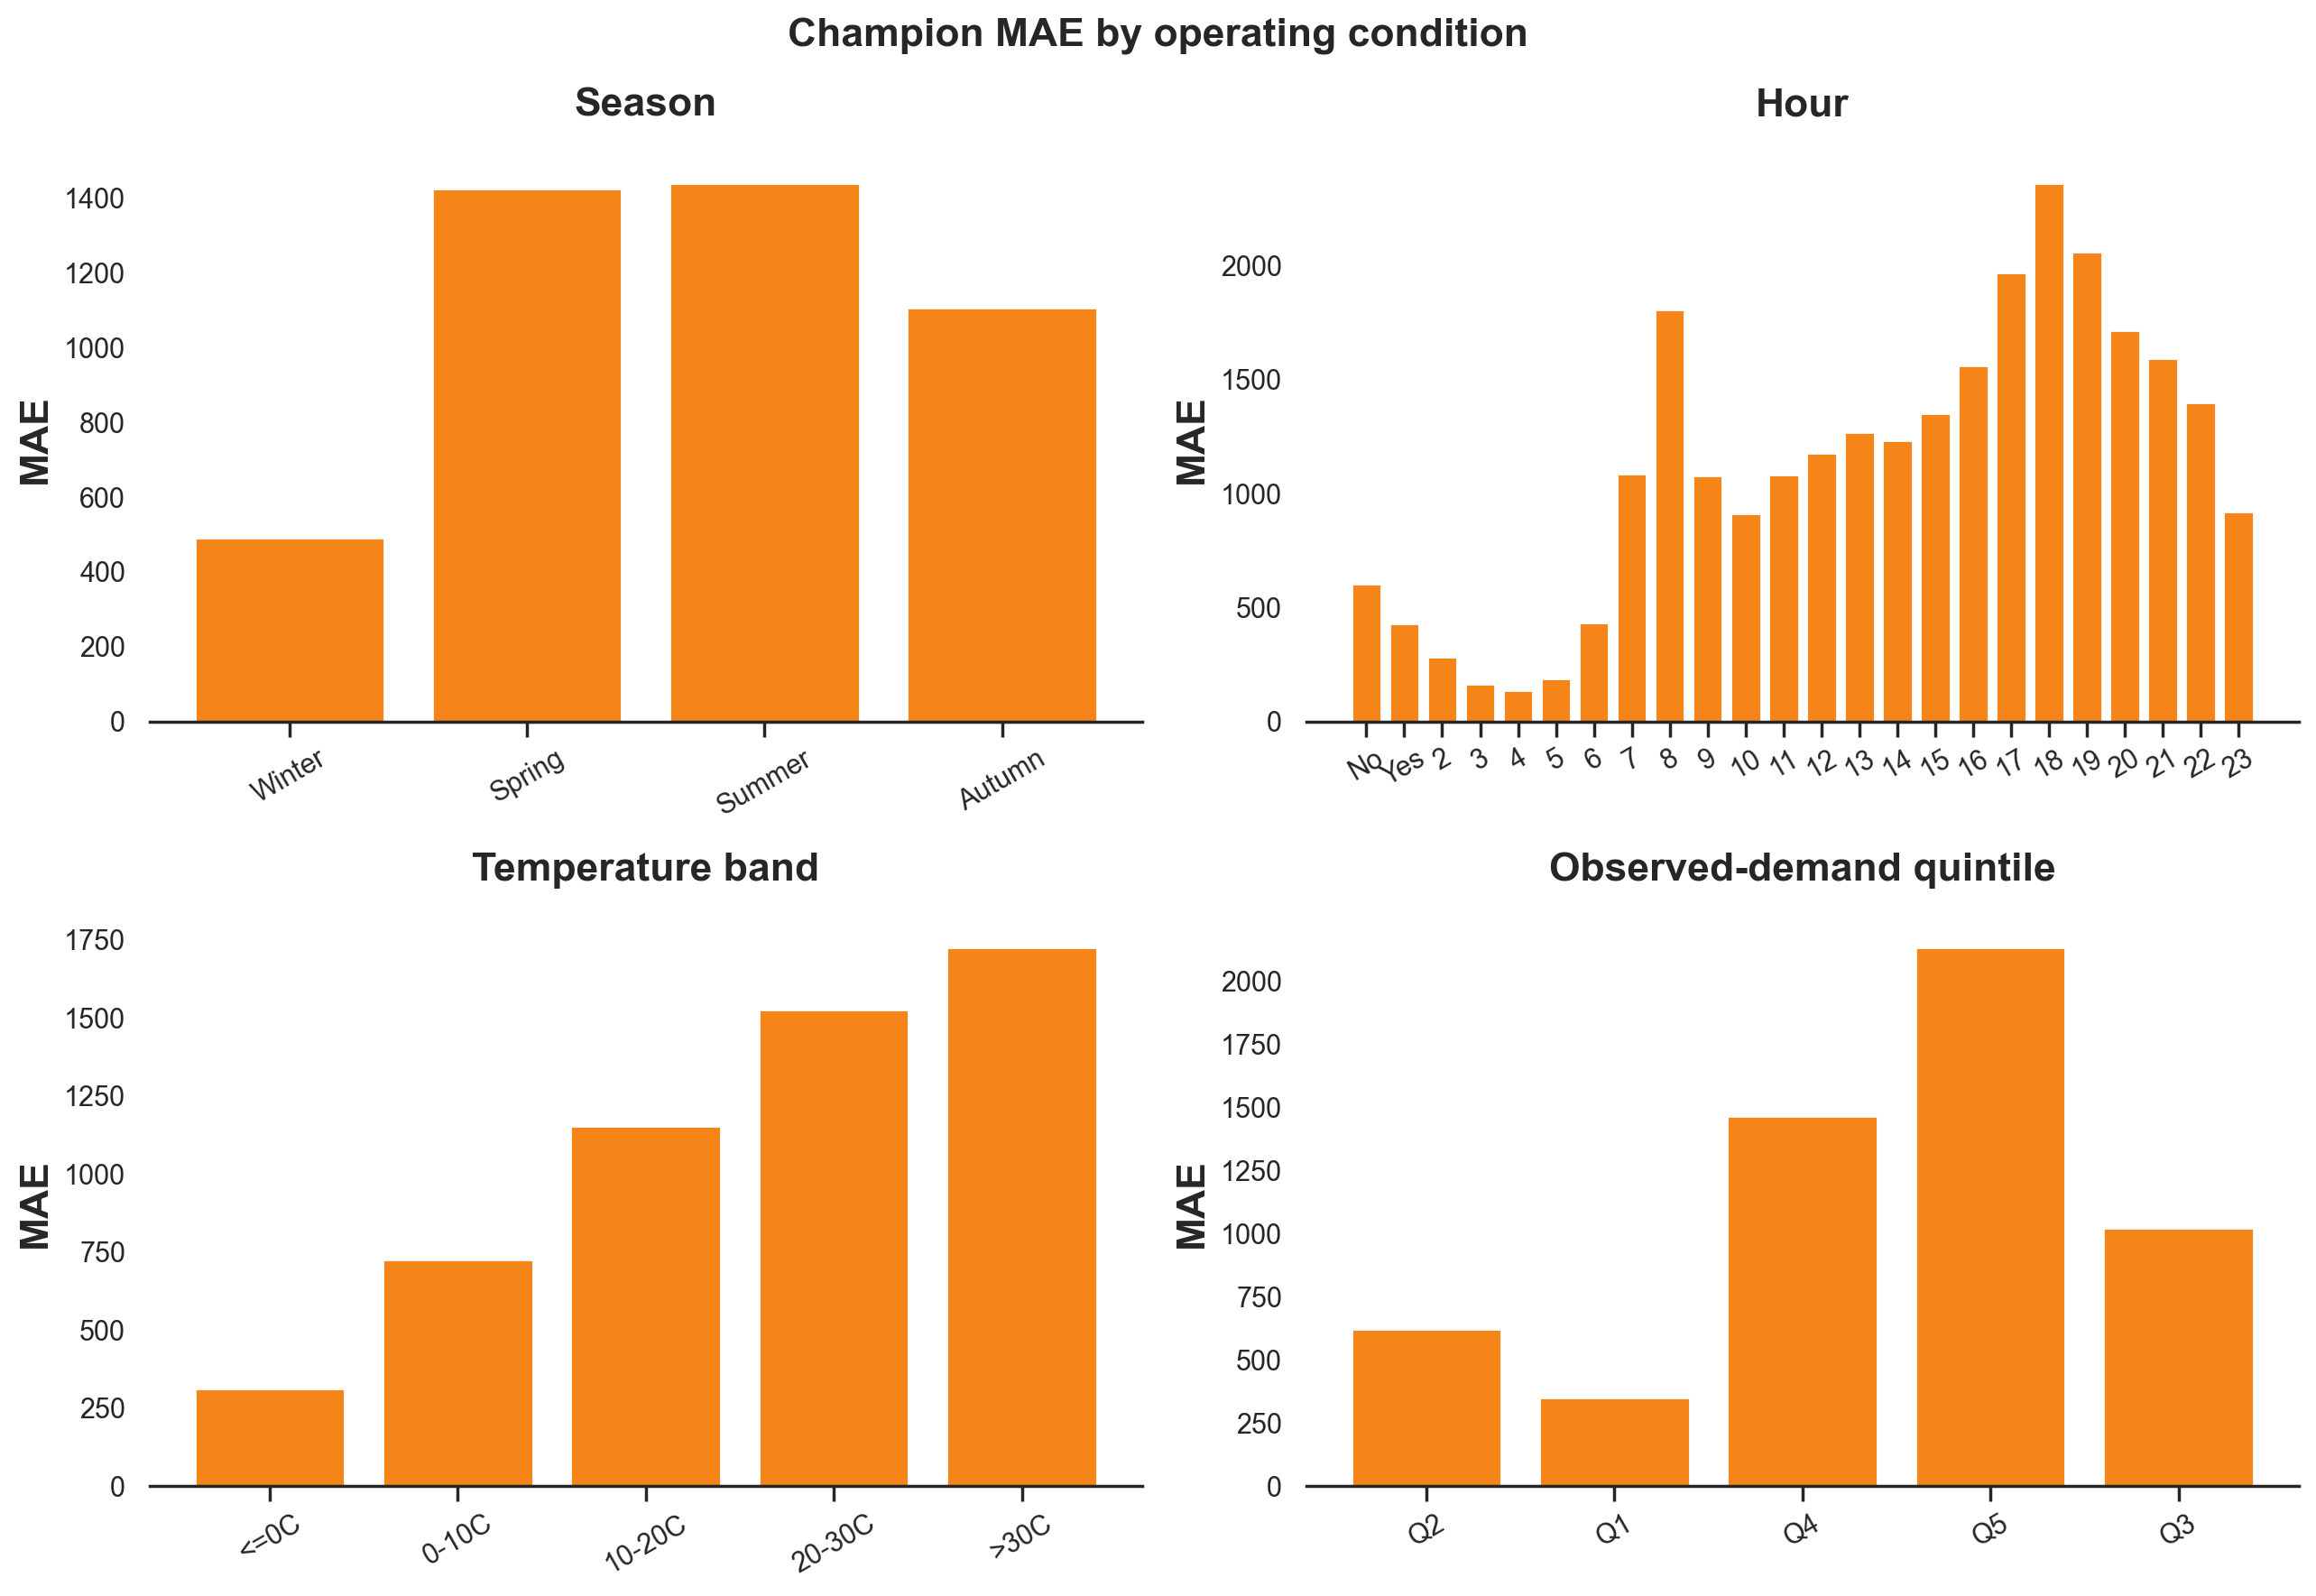

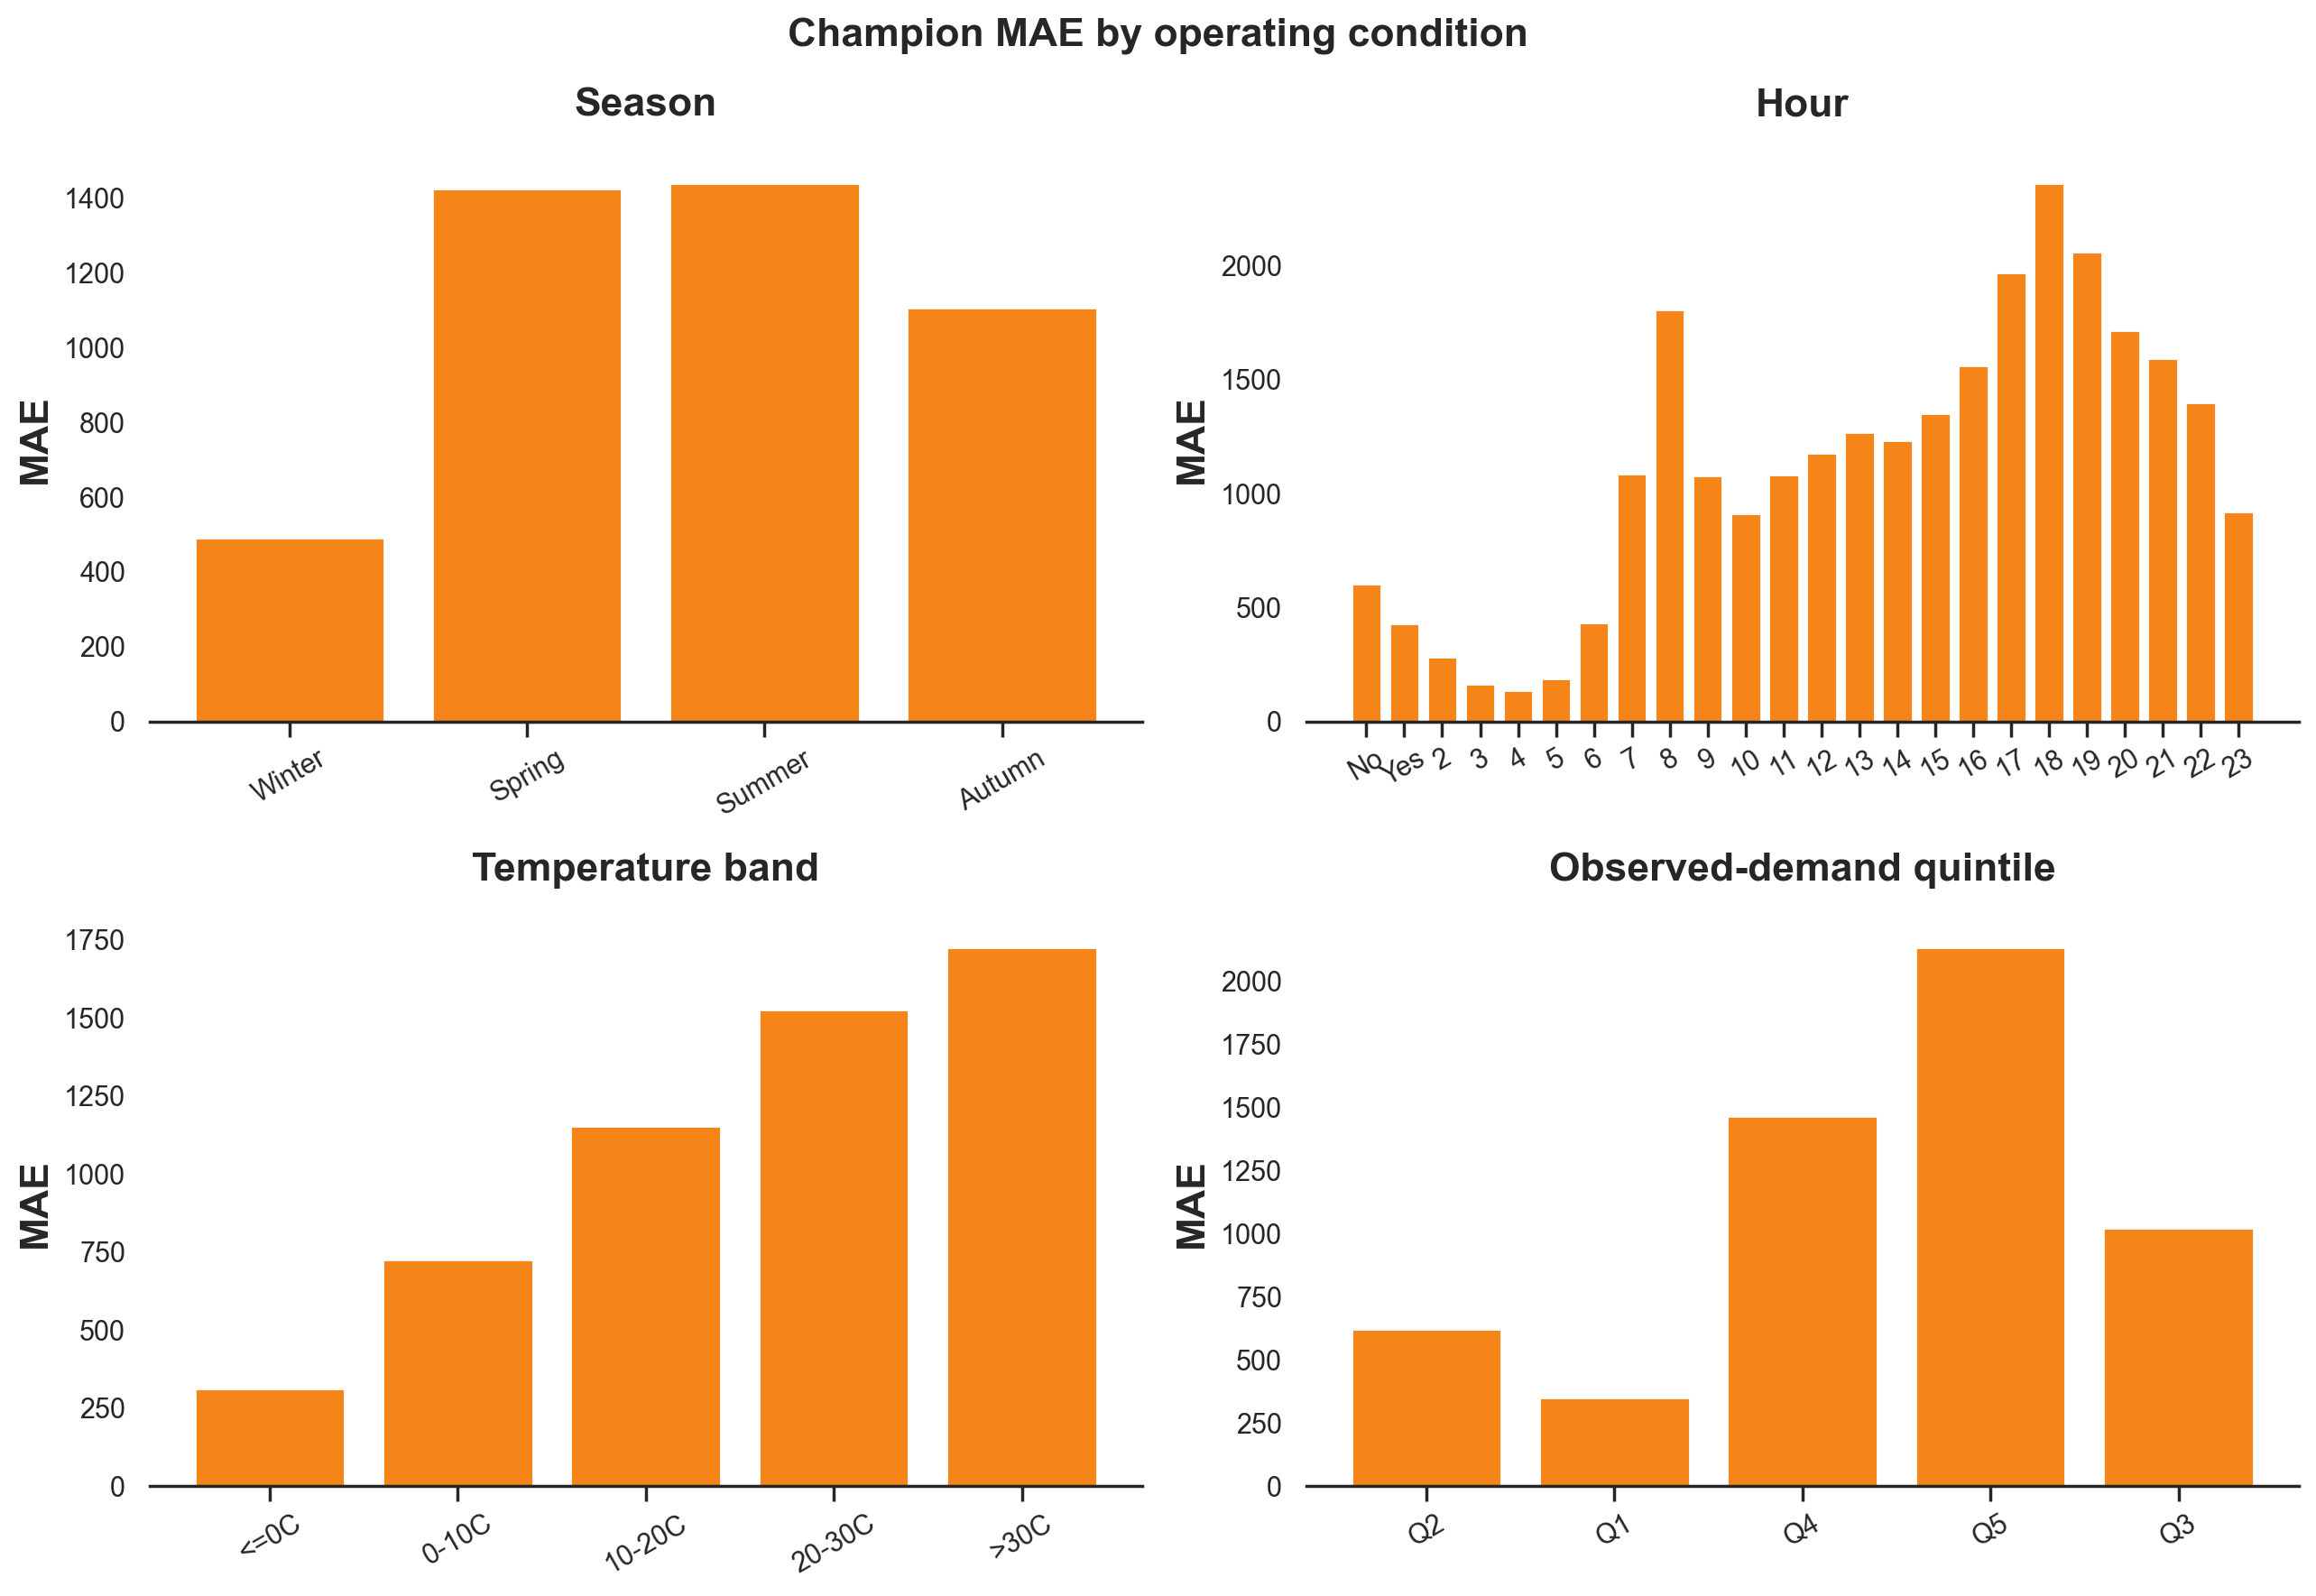

In [25]:
reports.plot_condition_metrics(results, lang=lang)

## 9. Prediction Decomposition and SHAP Methodology

Each candidate’s prediction is decomposed as log1p(prediction) = robust temporal baseline + residual-model prediction. SHAP values explain the residual-model prediction on the logarithmic residual scale and, because of the `expm1` transformation, are not directly additive on the bicycle-per-hour scale. Two identities are checked under strict numerical tolerances: the expected value plus the sum of SHAP values must reconstruct the core estimator’s prediction, and reconstruction from the baseline plus the residual must reproduce the outer pipeline’s prediction. Any additivity failure interrupts the workflow. SHAP values explain model behavior rather than causal relationships, and correlated features may share or redistribute attributions.


In [26]:
shap_results = run_shap_validation(results, config)
reports.shap_methodology_report(lang=lang)

,Item,Value
0,Prediction decomposition,log1p(prediction) = robust temporal baseline +...
1,What the SHAP values explain,the residual-model prediction on the logarithm...
2,Additivity scale,logarithmic residual scale
3,Not directly additive in,"bicycles/hour, because of the expm1 transforma..."
4,Verified identity (1),expected_value + Σ SHAP ≈ core-estimator predi...
5,Verified identity (2),"clip(expm1(baseline + residual), 0) ≈ outer-pi..."
6,Numerical tolerance,"rtol=1e-6, atol=1e-6"
7,Interpretation limitation,"the values explain model behavior, not causal ..."


In [27]:
reports.shap_additivity_report(shap_results, lang=lang)

,Role,Estimator,Observations in the sample,Transformed features,Maximum additivity error,Maximum reconstruction error
0,Champion,CatBoostRegressor,500,41,5.773160e-15,0.000000e+00
1,Challenger,HistGradientBoostingRegressor,500,41,1.110223e-14,0.000000e+00
2,Challenger,RandomForestRegressor,500,25,1.079137e-13,2.910383e-11


## 10. Global SHAP Importance

Global importance is reported both by transformed feature and by conceptual feature group. For the grouped ranking, contributions from periodic expansions of the same feature are summed observation by observation before the mean absolute value is computed. This preserves direction and additivity within each group. The leading conceptual features are also compared across the three candidates.


In [28]:
reports.shap_grouped_report(shap_results, lang=lang)

,Conceptual feature,Mean |SHAP| (grouped)
0,Hour,0.341607
1,Elapsed_Hours,0.304019
2,Month,0.173192
3,Time_Period,0.133843
4,Temperature(C),0.116347
5,Rainfall Cat,0.099444
6,Humidity(%),0.092603
7,Rush_Hour,0.081666
8,Cloud Cover (oktas),0.072296
9,Rush_Period,0.063275


In [29]:
reports.shap_detailed_report(shap_results, lang=lang)

,Transformed feature,mean |SHAP|
0,Elapsed_Hours,0.304019
1,Hour_spline_03,0.230632
2,Time_Period,0.133843
3,Temperature(C),0.116347
4,Rainfall Cat,0.099444
5,Hour_spline_02,0.093387
6,Humidity(%),0.092603
7,Rush_Hour,0.081666
8,Cloud Cover (oktas),0.072296
9,Hour_spline_10,0.069242


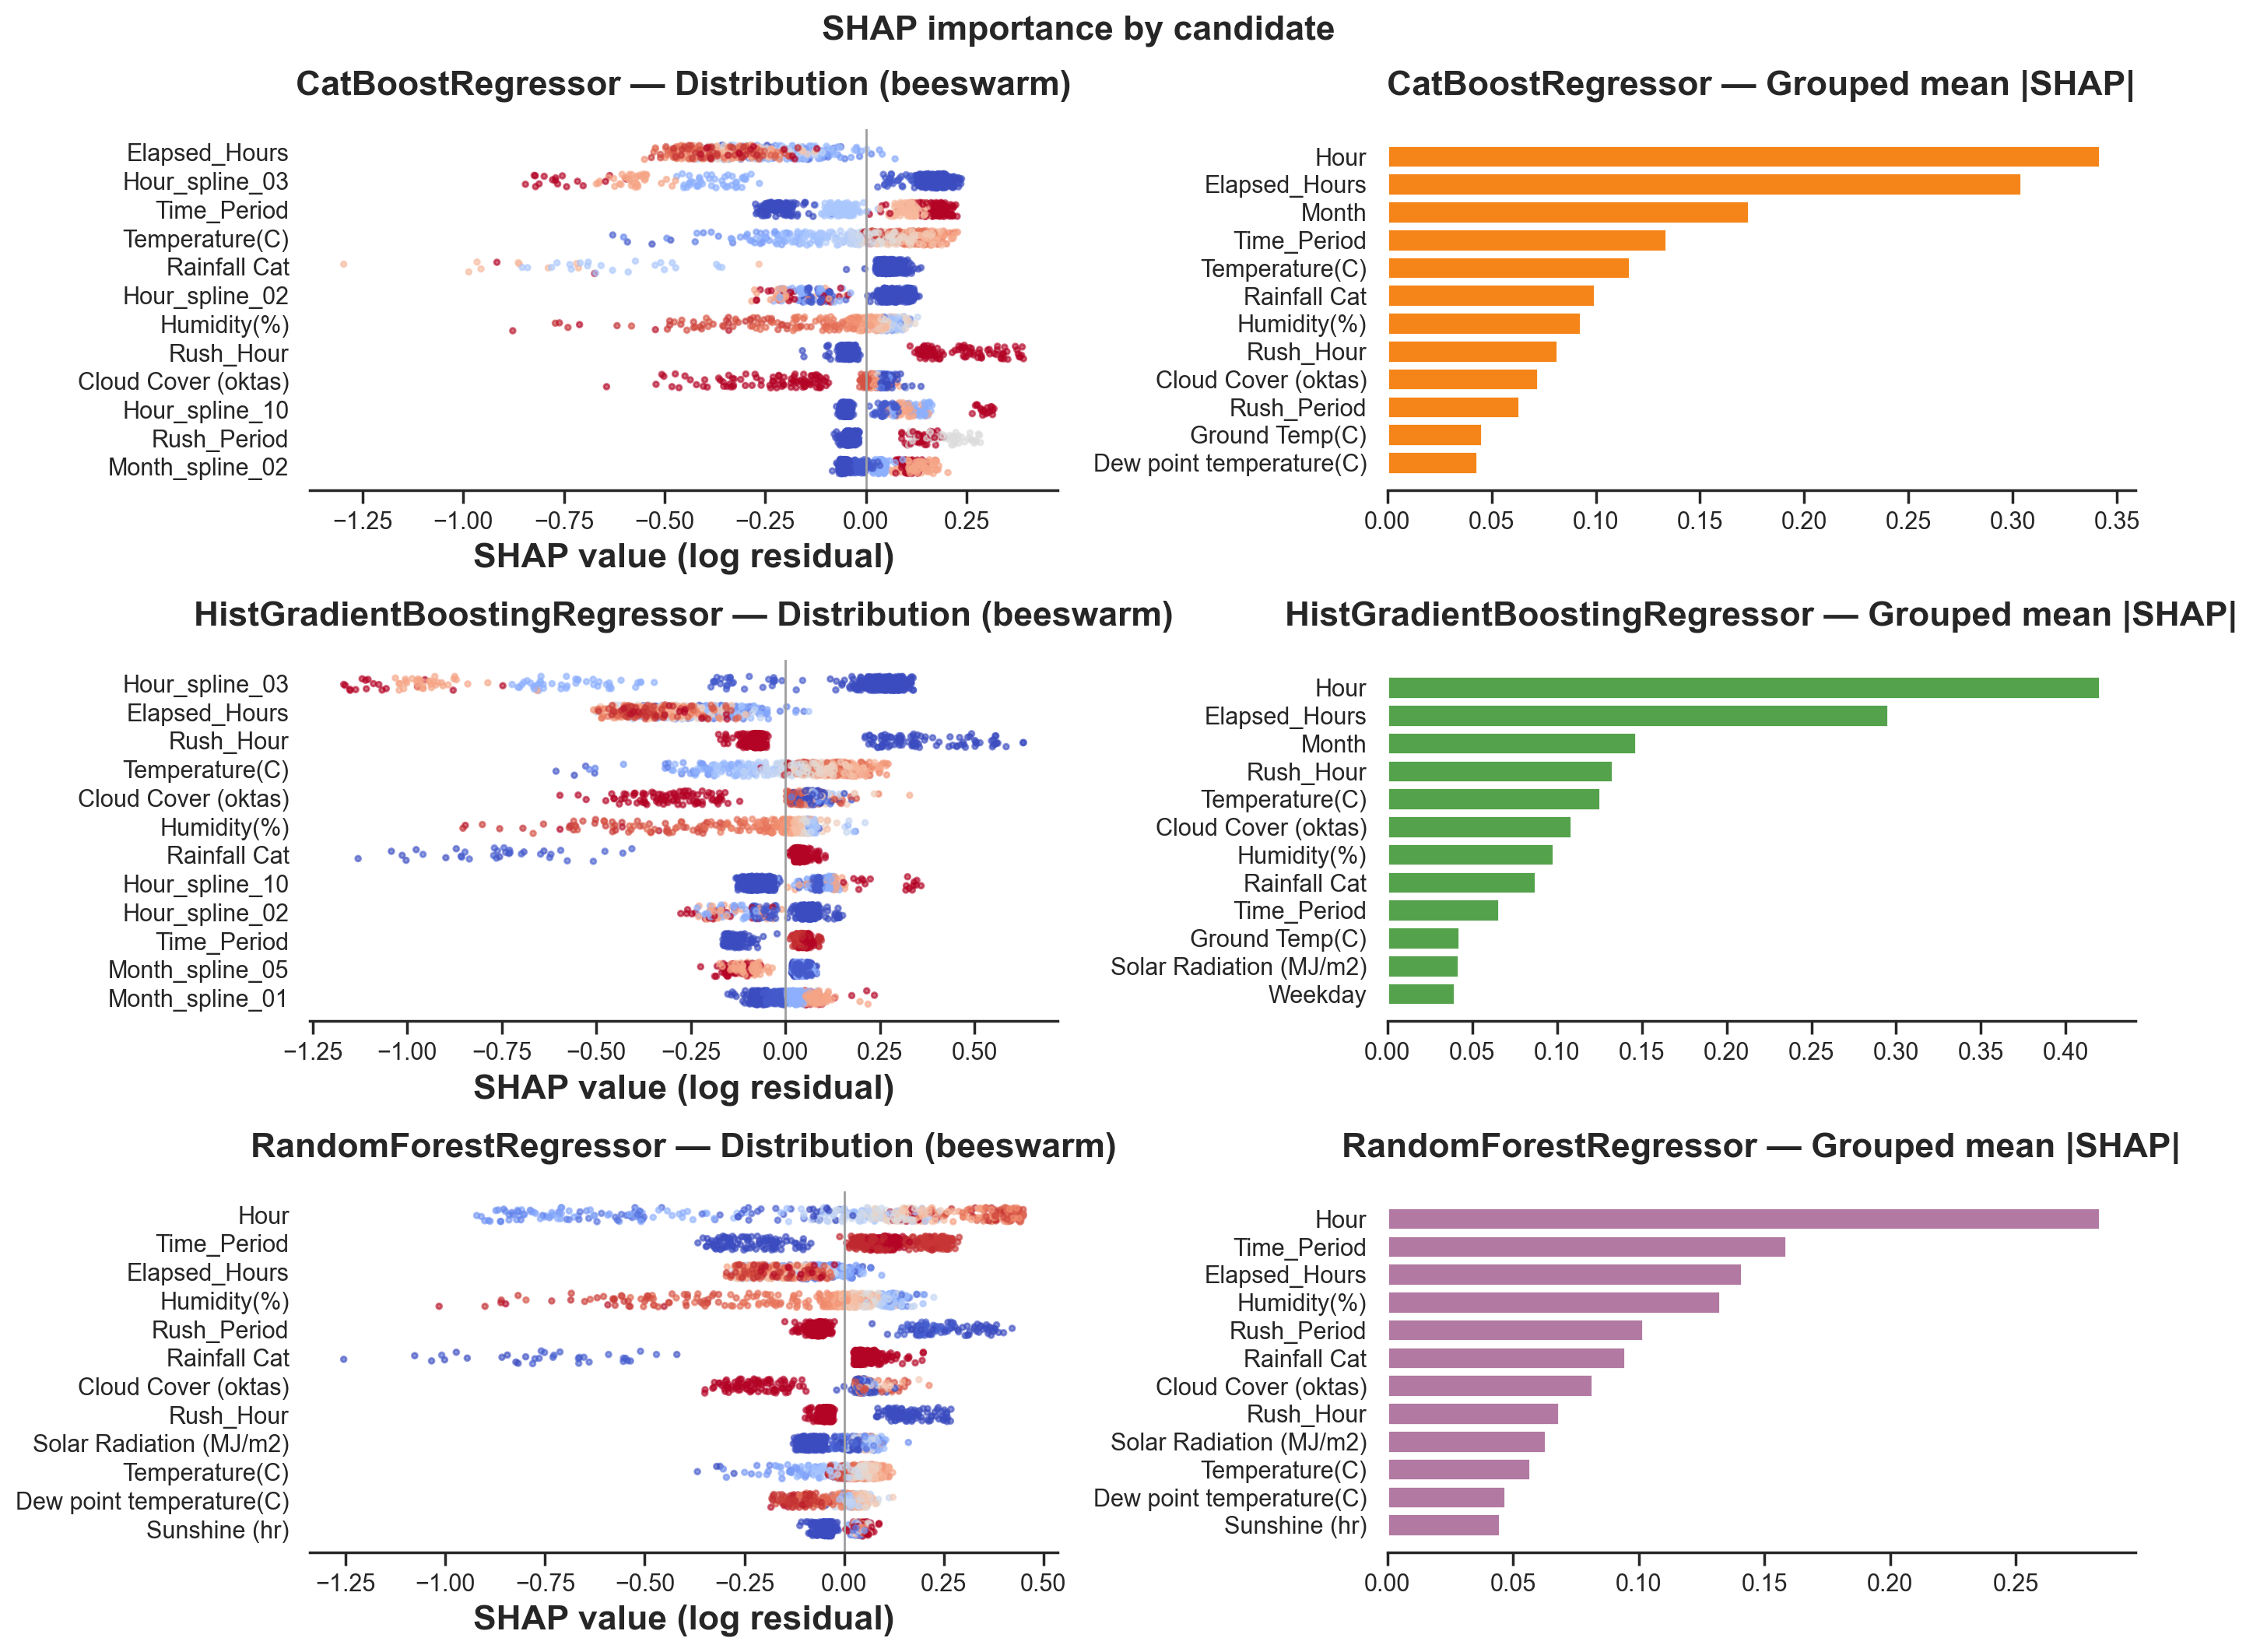

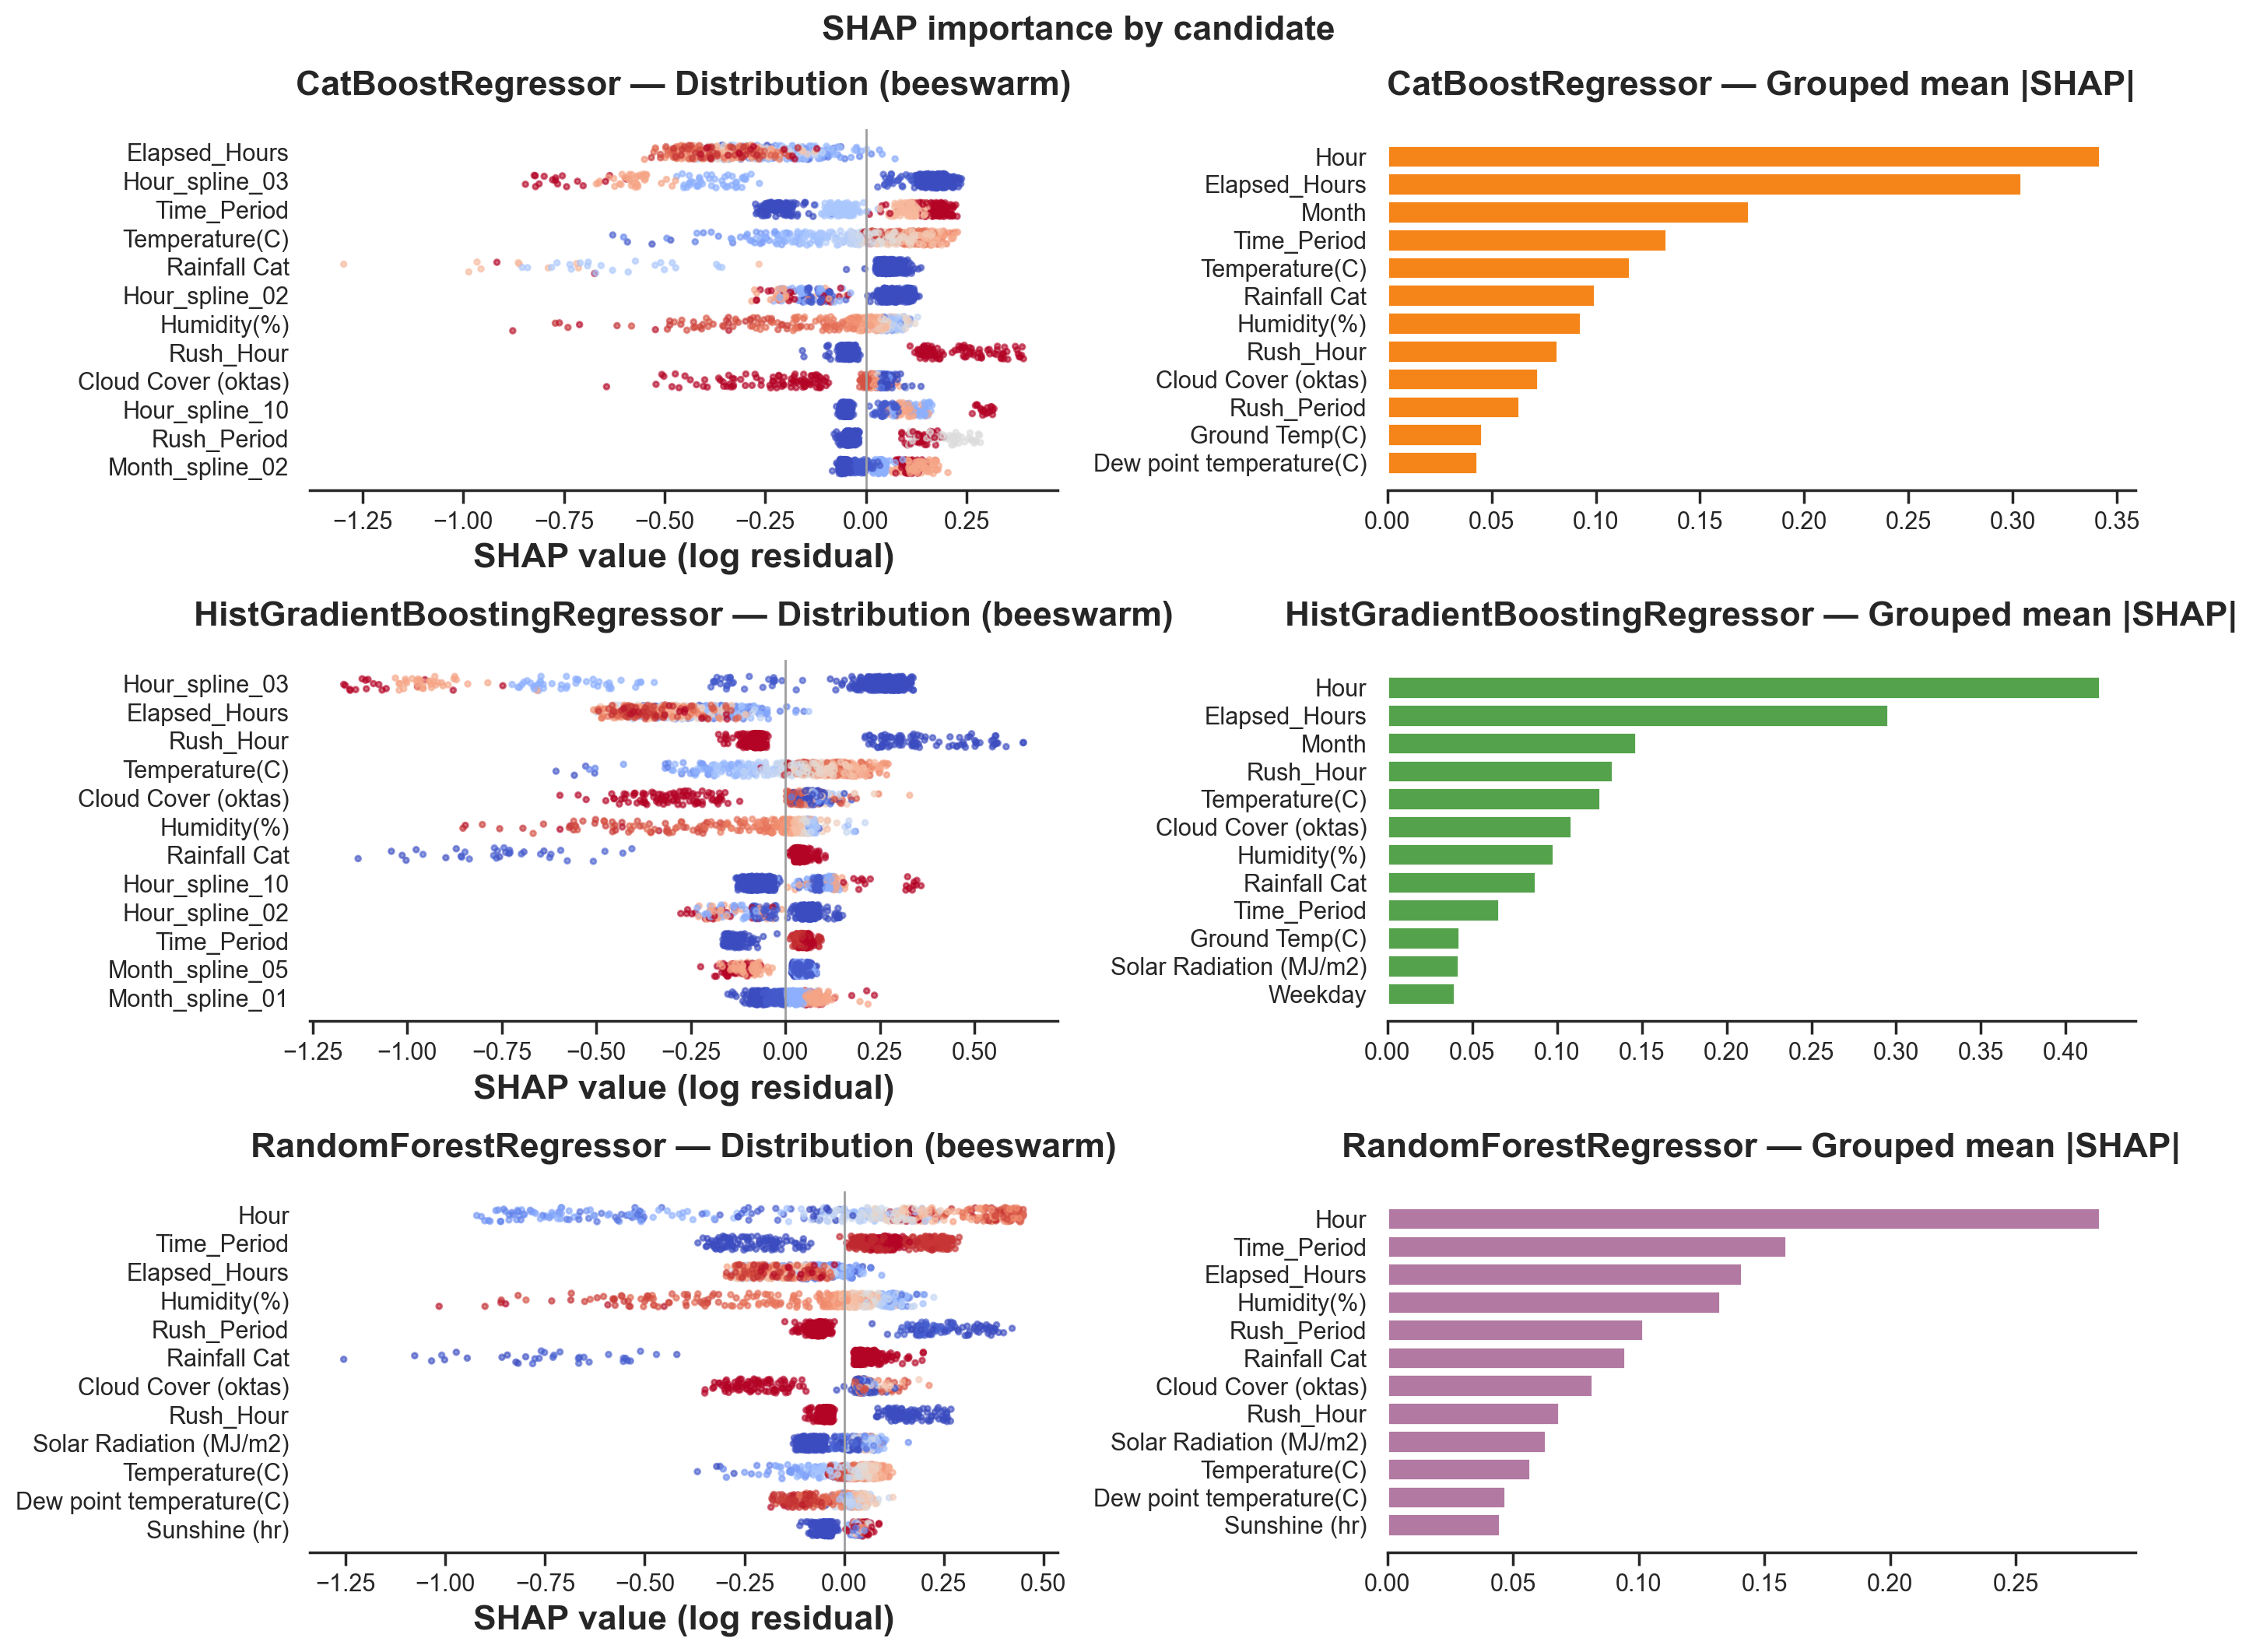

In [30]:
reports.plot_shap_summary(shap_results, lang=lang)

In [31]:
reports.shap_feature_comparison_report(shap_results, lang=lang)

,Conceptual feature,CatBoostRegressor,HistGradientBoostingRegressor,RandomForestRegressor
0,Cloud Cover (oktas),0.072296,0.108650,0.081562
1,Elapsed_Hours,0.304019,0.294967,0.140928
2,Hour,0.341607,0.419887,0.283376
3,Humidity(%),0.092603,0.097876,0.132214
4,Month,0.173192,0.146472,0.018465
5,Rainfall Cat,0.099444,0.087315,0.094667
6,Rush_Hour,0.081666,0.132615,0.068254
7,Rush_Period,0.063275,0.008852,0.101596
8,Temperature(C),0.116347,0.125238,0.056777
9,Time_Period,0.133843,0.065981,0.158741


## 11. Local SHAP Explanations

In addition to the global sample, local explanations are produced for the pre-registered Champion at an observation near the median absolute error, at the largest underestimation, and at the largest overestimation. The displayed contributions are attributions to the logarithmic residual, not to bicycle demand per hour, as stated in the plot titles.


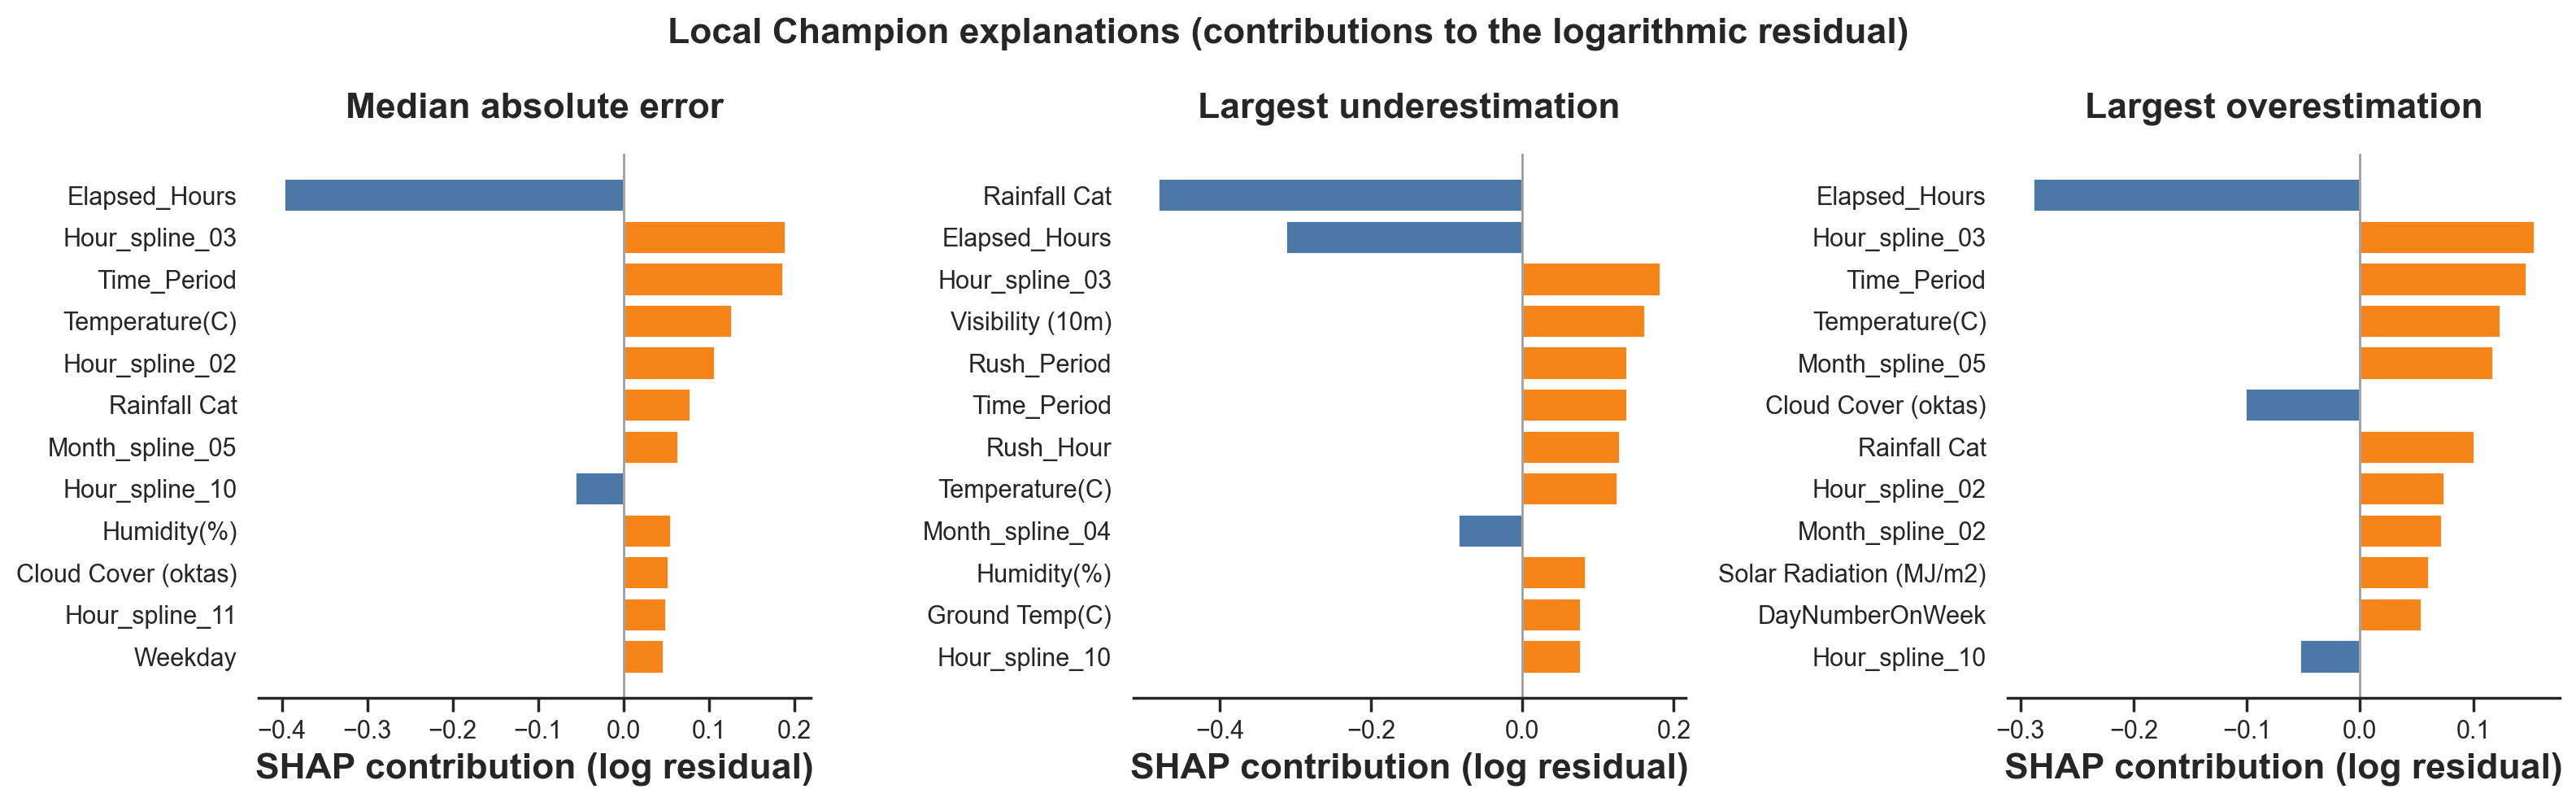

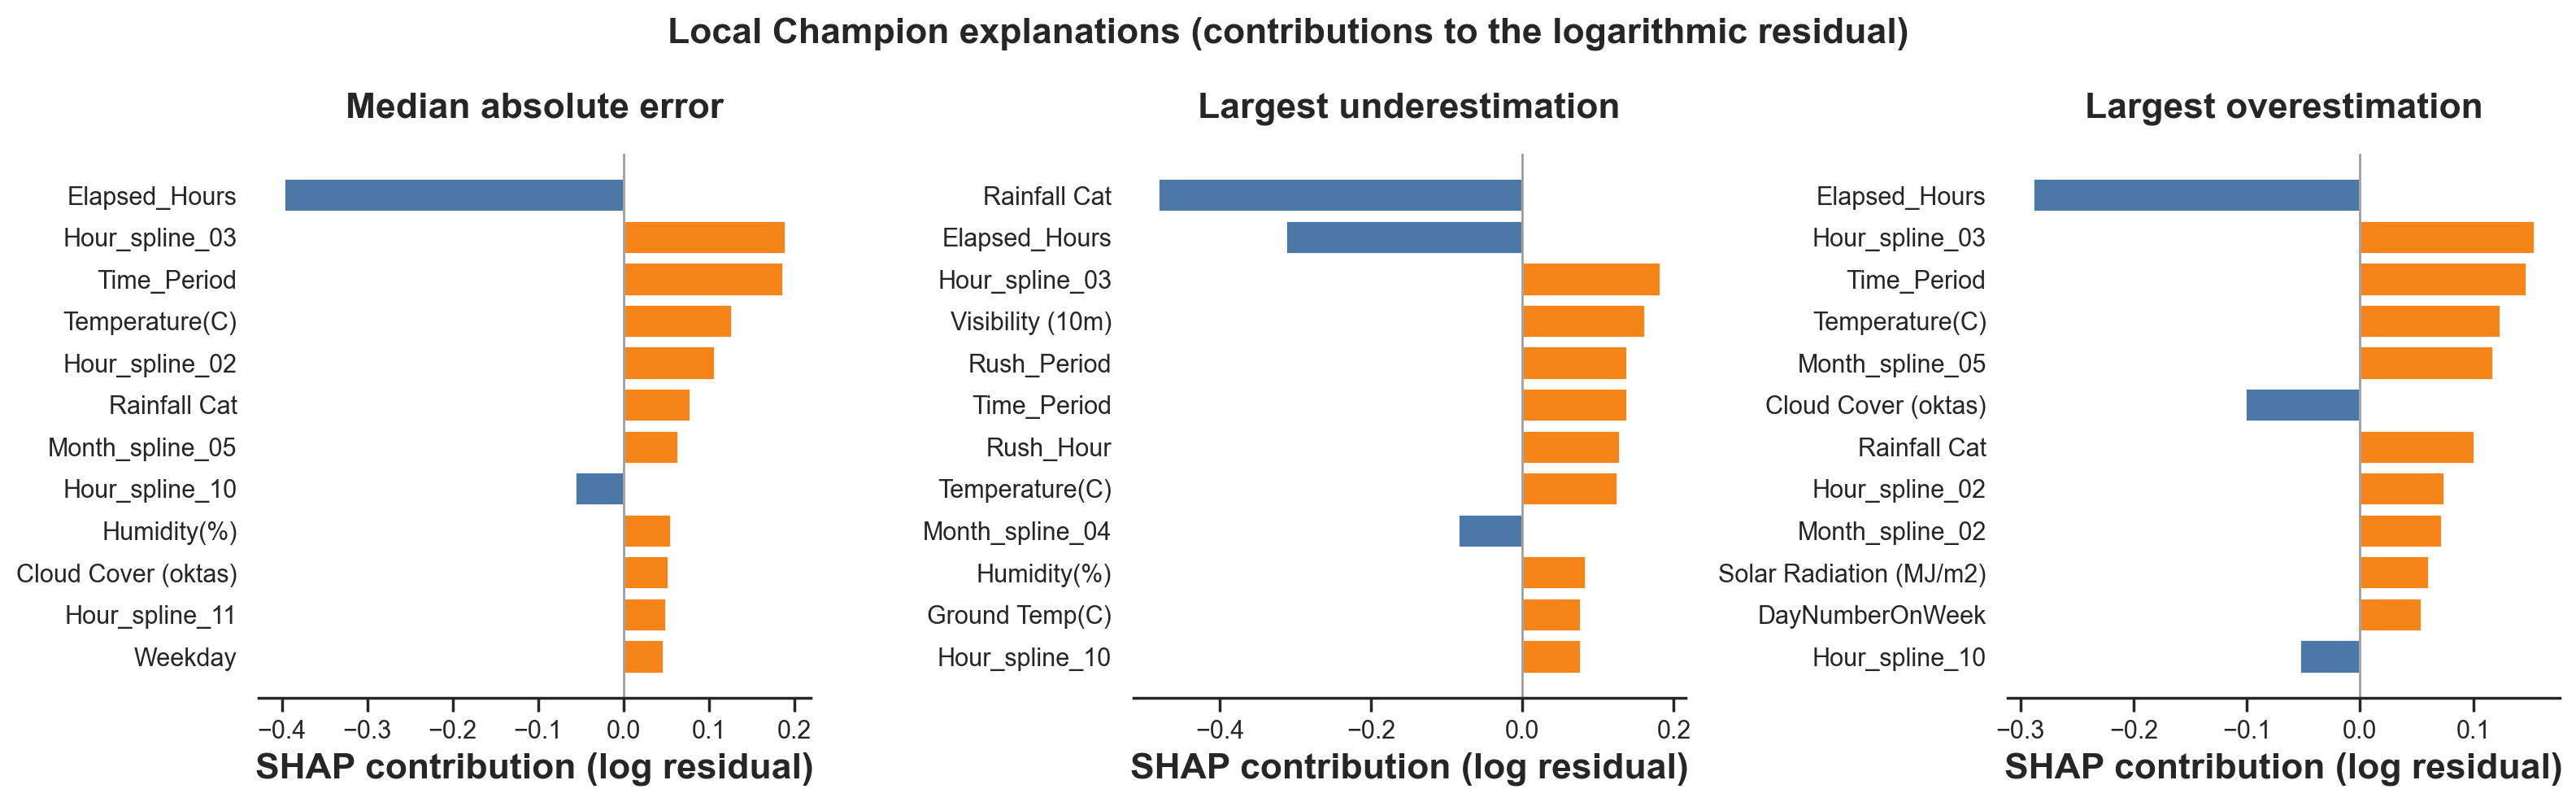

In [32]:
reports.plot_shap_local(results, shap_results, lang=lang)

## 12. MLflow Tracking and Final Artifacts

Results are persisted in a dedicated runtime directory and logged to an MLflow experiment reserved for final validation, with one parent run and one child run per candidate. Models are not registered again because the frozen artifacts already exist and are referenced by identifier, path, and hash. Selection runs are not modified.


In [33]:
reports.artifacts_report(results, lang=lang)

,Item,Value
0,Runtime directory,dataset/normal_operations/final_validation_v4
1,Final manifest,dataset/normal_operations/final_validation_v4/...
2,MLflow experiment,bike_sharing_demand_v4_final_validation
3,Parent run (MLflow),694315351bfe4b24b2df9ae098ecf7f5
4,Child runs (MLflow),"b886c7c303e34535808468465f6252ab, 1ad1a501b92f..."
5,Result source,reused from cache
6,Recorded decision,Champion confirmed


## 13. Synthesis

The synthesis consolidates the confirmatory decision, the Champion’s holdout position, its distance from the closest candidate, and the residual limitations identified after final validation. CatBoost’s confirmation is preserved as a point-prediction decision; at the same time, systematic bias, residual autocorrelation, and heteroscedasticity prevent IID-based intervals from being treated as validated.

The handoff message summarizes the outcome and its limitations while preserving the Notebook 04 manifest unchanged. Any future model change should be treated as a new experimental version, validated through development backtesting and subsequently confirmed in an independent temporal window.


In [34]:
reports.synthesis_report(results, lang=lang)

,Item,Value
0,Final decision,Champion confirmed
1,Champion,CatBoostRegressor
2,Champion holdout MAE,1118.087
3,Champion holdout R²,0.8393
4,Best on the holdout,CatBoostRegressor
5,MAE difference from the best candidate,0.0
6,|bias| / Champion MAE,0.8945
7,Residual Durbin–Watson,0.4072
8,Validated IID intervals,False
9,New independent window required,False


In [35]:
reports.handoff_message(results, lang=lang)

'Final validation confirms the pre-registered Champion under the confirmatory protocol, measured exactly once on the sealed temporal holdout. Results were persisted and logged to a dedicated MLflow experiment without modifying any selection run. Residual screening indicates a predominant shift toward overestimation; |bias| represents 89.4% of the Champion MAE. After removal of the mean weekly pattern, lag-168 autocorrelation was reduced by 41.7%; after standardization by predicted level, the mean ARCH indicator was reduced by 48.3%, but evidence of conditional clustering remained. CatBoost remains confirmed only as the best point predictor under the current protocol; intervals under the IID assumption have not yet been validated.'

### Methodological References

Breusch, T. S.; Pagan, A. R. (1979). A Simple Test for Heteroscedasticity and Random Coefficient Variation. *Econometrica*, 47(5), 1287–1294.

White, H. (1980). A Heteroskedasticity-Consistent Covariance Matrix Estimator and a Direct Test for Heteroskedasticity. *Econometrica*, 48(4), 817–838.

Goldfeld, S. M.; Quandt, R. E. (1965). Some Tests for Homoscedasticity. *Journal of the American Statistical Association*, 60(310), 539–547.

Engle, R. F. (1982). Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation. *Econometrica*, 50(4), 987–1007.

Lundberg, S. M.; Lee, S.-I. (2017). A Unified Approach to Interpreting Model Predictions. *NeurIPS*.

Lundberg, S. M. et al. (2020). From local explanations to global understanding with explainable AI for trees. *Nature Machine Intelligence*.
